In [9]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import rcParams
from astropy.table import Table
from astropy.io import fits
import seaborn as sns
from matplotlib.animation import PillowWriter
import matplotlib as mpl
from matplotlib.ticker import FormatStrFormatter
from matplotlib.colors import TwoSlopeNorm
import matplotlib.colors as mcolors
import random
import jax

import pollux as plx
from pollux.models.transforms import LinearTransform

jax.config.update("jax_enable_x64", True)

params = {
   'axes.labelsize': 15,
   'font.size': 15,
   'legend.fontsize': 14,
   'xtick.minor.visible': True,
   'ytick.minor.visible': True,
   'xtick.labelsize': 15,
   'ytick.labelsize': 15,
   'text.usetex': True, #to use TeX in your labels
   'font.family':'serif',
   'axes.titlesize': 15,
   'xtick.direction': 'in',
   'ytick.direction': 'in',
   'xtick.top': True,
   'ytick.right': True,
   'xtick.major.size': 6,
   'xtick.minor.size': 3,
   'ytick.major.size': 6,
   'ytick.minor.size': 3
   }
rcParams.update(params)


def decode(df):
    """
    Decode DataFrame with byte strings into ordinary strings.
    """
    for col in df.columns:
        if df[col].dtype == object:
            decoded_values = []
            for item in df[col]:
                if isinstance(item, bytes):
                    decoded_values.append(item.decode('utf-8'))
                else:
                    decoded_values.append(item)
            df[col] = decoded_values
            
    return df

def fitsrec_to_pandas(fits_rec):
    """
    Convert a FITS_rec object (from astropy.io.fits) to a pandas DataFrame.
    """
    # Convert FITS_rec to astropy Table first
    table = Table(fits_rec)
    
    # Filter out multidimensional columns
    cols = [name for name in table.colnames if len(table[name].shape) <= 1]
    
    # Convert to pandas DataFrame
    df = table[cols].to_pandas()
    
    # Decode byte strings
    df = decode(df)
    
    return df

def compute_binned_median(df, x_col, y_col, n_bins=12):
    """
    Bin df[x_col] into n_bins, then compute median of df[y_col] in each bin,
    and also return the number of points in each bin.

    Returns columns:
    ['x_bin', f'{y_col}_median', 'x_center', 'count']
    """
    
    # Create bins
    x_bins = np.linspace(df[x_col].min(), df[x_col].max(), n_bins + 1)

    # Bin using pd.cut
    x_bin_labels = pd.cut(df[x_col], bins=x_bins, include_lowest=True)

    # Group by bins and compute median AND count
    grouped = df.groupby(x_bin_labels).agg(
        y_median=(y_col, 'median'),
        count=(y_col, 'size')
    ).reset_index()

    # Add x_center using bin midpoint
    grouped['x_center'] = grouped[x_col].apply(lambda interval: interval.mid)

    # Rename bin column
    grouped = grouped.rename(columns={x_col: 'x_bin', 'y_median': f"{y_col}_median"})

    return grouped


In [10]:
with fits.open('data/astroNN_2proc_crossmatch.fits') as hdul:
    astronn_data = hdul[1].data
    twoprocess_data = hdul[2].data

two_process_data = fitsrec_to_pandas(twoprocess_data)
data_astronn = fitsrec_to_pandas(astronn_data)

# Identify columns that are NOT already in two_process_data
#new_cols = data_astronn.columns.difference(two_process_data.columns)
new_cols = ['galr', 'galz']


# Concatenate, keeping two_process_data's versions of duplicate columns
data = pd.concat(
    [
        two_process_data.reset_index(drop=True),
        data_astronn[new_cols].reset_index(drop=True)
    ],
    axis=1
)

data = data[data['DFLAG'] == 0]

data['MG_H'] = data['MG_H_ASPCAP_ADJ']
data['FE_H'] = data['FE_H_ASPCAP_ADJ']
data['MN_H'] = data['MN_H_ASPCAP_ADJ']
data['NI_H'] = data['NI_H_ASPCAP_ADJ']
data['AL_H'] = data['AL_H_ASPCAP_ADJ']

data['MN_O'] = data['MN_H_ASPCAP_ADJ'] - data['O_H_ASPCAP_ADJ']
data['FE_O'] = data['FE_H_ASPCAP_ADJ'] - data['O_H_ASPCAP_ADJ']
data['MN_MG'] = data['MN_H_ASPCAP_ADJ'] - data['MG_H_ASPCAP_ADJ']
data['FE_MG'] = data['FE_H_ASPCAP_ADJ'] - data['MG_H_ASPCAP_ADJ']
data['MG_FE'] = data['MG_H_ASPCAP_ADJ'] - data['FE_H_ASPCAP_ADJ']
data['MN_FE'] = data['MN_H_ASPCAP_ADJ'] - data['FE_H_ASPCAP_ADJ']
data['NI_MG'] = data['NI_H_ASPCAP_ADJ'] - data['MG_H_ASPCAP_ADJ']
data['NI_FE'] = data['NI_H_ASPCAP_ADJ'] - data['FE_H_ASPCAP_ADJ']
data['AL_MG'] = data['AL_H_ASPCAP_ADJ'] - data['MG_H_ASPCAP_ADJ']
data['AL_FE'] = data['AL_H_ASPCAP_ADJ'] - data['FE_H_ASPCAP_ADJ']

data = data[(data['galz'] < 2) & (data['galz'] > -2) & (data['galr'] < 15) & (data['galr'] > 3)]

pos_FE_H = data[(data['FE_H'] > 0)]
neg_FE_H = data[(data['FE_H'] < 0)]
data_high_alpha = pd.concat([pos_FE_H[(pos_FE_H['MG_FE'] > 0.12)], neg_FE_H[neg_FE_H['MG_FE'] > 0.12 - 0.13 * neg_FE_H['FE_H']]])
data_low_alpha = pd.concat([pos_FE_H[(pos_FE_H['MG_FE'] < 0.12)], neg_FE_H[neg_FE_H['MG_FE'] < 0.12 - 0.13 * neg_FE_H['FE_H']]])


data_high_alpha['high_low_alpha'] = "high"
data_low_alpha['high_low_alpha'] = "low"
data_high_alpha['color'] = "hotpink"
data_low_alpha['color'] = "cornflowerblue"

sdss_adj_data = pd.concat([data_high_alpha, data_low_alpha], ignore_index=True)

In [11]:
training_dwarfs_sdss = pd.read_pickle('data/training_set_dwarfs.pkl')
training_giants_sdss = pd.read_pickle('data/training_set_giants.pkl')

lux_pred_giants = pd.read_csv("data/giants_predicted_with_alpha_m.csv")
lux_pred_dwarfs = pd.read_csv("data/dwarfs_predicted_with_alpha_m.csv")

In [12]:
training_dwarfs_sdss['alpha_h'] = training_dwarfs_sdss['alpha_m_atm'] + training_dwarfs_sdss['m_h_atm']
training_dwarfs_sdss['fe_mg'] = training_dwarfs_sdss['fe_h'] - training_dwarfs_sdss['mg_h']
training_dwarfs_sdss['mg_fe'] = training_dwarfs_sdss['mg_h'] - training_dwarfs_sdss['fe_h']
training_dwarfs_sdss['fe_alpha'] = training_dwarfs_sdss['fe_h'] - training_dwarfs_sdss['alpha_h']
training_dwarfs_sdss['alpha_fe'] = training_dwarfs_sdss['alpha_h'] - training_dwarfs_sdss['fe_h']

training_giants_sdss['alpha_h'] = training_giants_sdss['alpha_m_atm'] + training_giants_sdss['m_h_atm']
training_giants_sdss['fe_mg'] = training_giants_sdss['fe_h'] - training_giants_sdss['mg_h']
training_giants_sdss['alpha_fe'] = training_giants_sdss['alpha_h'] - training_giants_sdss['fe_h']
training_giants_sdss['fe_alpha'] = training_giants_sdss['fe_h'] - training_giants_sdss['alpha_h']
training_giants_sdss['mg_fe'] = training_giants_sdss['mg_h'] - training_giants_sdss['fe_h']
training_giants_sdss['fe_alpha'] = training_giants_sdss['fe_h'] - training_giants_sdss['alpha_h']


lux_pred_giants['alpha_h'] = lux_pred_giants['alpha_m_atm'] + lux_pred_giants['m_h_atm']
lux_pred_giants['alpha_fe'] = lux_pred_giants['alpha_h'] - lux_pred_giants['fe_h']
lux_pred_giants['mg_fe'] = lux_pred_giants['mg_h'] - lux_pred_giants['fe_h']
lux_pred_giants['fe_mg'] = lux_pred_giants['fe_h'] - lux_pred_giants['mg_h']
lux_pred_giants['fe_alpha'] = lux_pred_giants['fe_h'] - lux_pred_giants['alpha_h']


lux_pred_dwarfs['alpha_h'] = lux_pred_dwarfs['alpha_m_atm'] + lux_pred_dwarfs['m_h_atm']
lux_pred_dwarfs['alpha_fe'] = lux_pred_dwarfs['alpha_h'] - lux_pred_dwarfs['fe_h']
lux_pred_dwarfs['mg_fe'] = lux_pred_dwarfs['mg_h'] - lux_pred_dwarfs['fe_h']
lux_pred_dwarfs['fe_mg'] = lux_pred_dwarfs['fe_h'] - lux_pred_dwarfs['mg_h']
lux_pred_dwarfs['fe_alpha'] = lux_pred_dwarfs['fe_h'] - lux_pred_dwarfs['alpha_h']

In [13]:
training_sdss_all = pd.concat([training_giants_sdss, training_dwarfs_sdss], ignore_index=True)
lux_pred_all = pd.concat([lux_pred_giants, lux_pred_dwarfs], ignore_index=True)

# Read file with R_guide and Z_max

In [ ]:
with fits.open("data/dr3-rv-all-partial-actions.fits") as hdul:
    hdul1 = hdul[1].data

orbit_df = fitsrec_to_pandas(hdul1)

In [ ]:
hdul1_pd = fitsrec_to_pandas(hdul1)

In [23]:
orbit_df = hdul1_pd
orbit_df.head()

,source_id,R_guide,z_max,r_per,r_apo,ecc,E,flags
0,38655544960,9.120762,0.331513,7.574346,11.429293,0.202853,-121124.876633,0
1,2851858288640,10.274976,0.323255,8.289310,13.367533,0.234486,-114956.286860,0
2,3332894779520,8.090165,0.385255,7.600019,8.751218,0.070404,-128634.044165,0
3,3371550165888,7.817885,0.916918,5.717990,12.505161,0.372448,-122554.683321,0
4,4711579935744,7.464825,2.346336,6.582459,10.467744,0.227873,-126194.693434,0


In [24]:
lux_pred_all = lux_pred_all.merge(orbit_df, on='source_id', how='left')
training_sdss_all = training_sdss_all.merge(orbit_df, on='source_id', how='left')

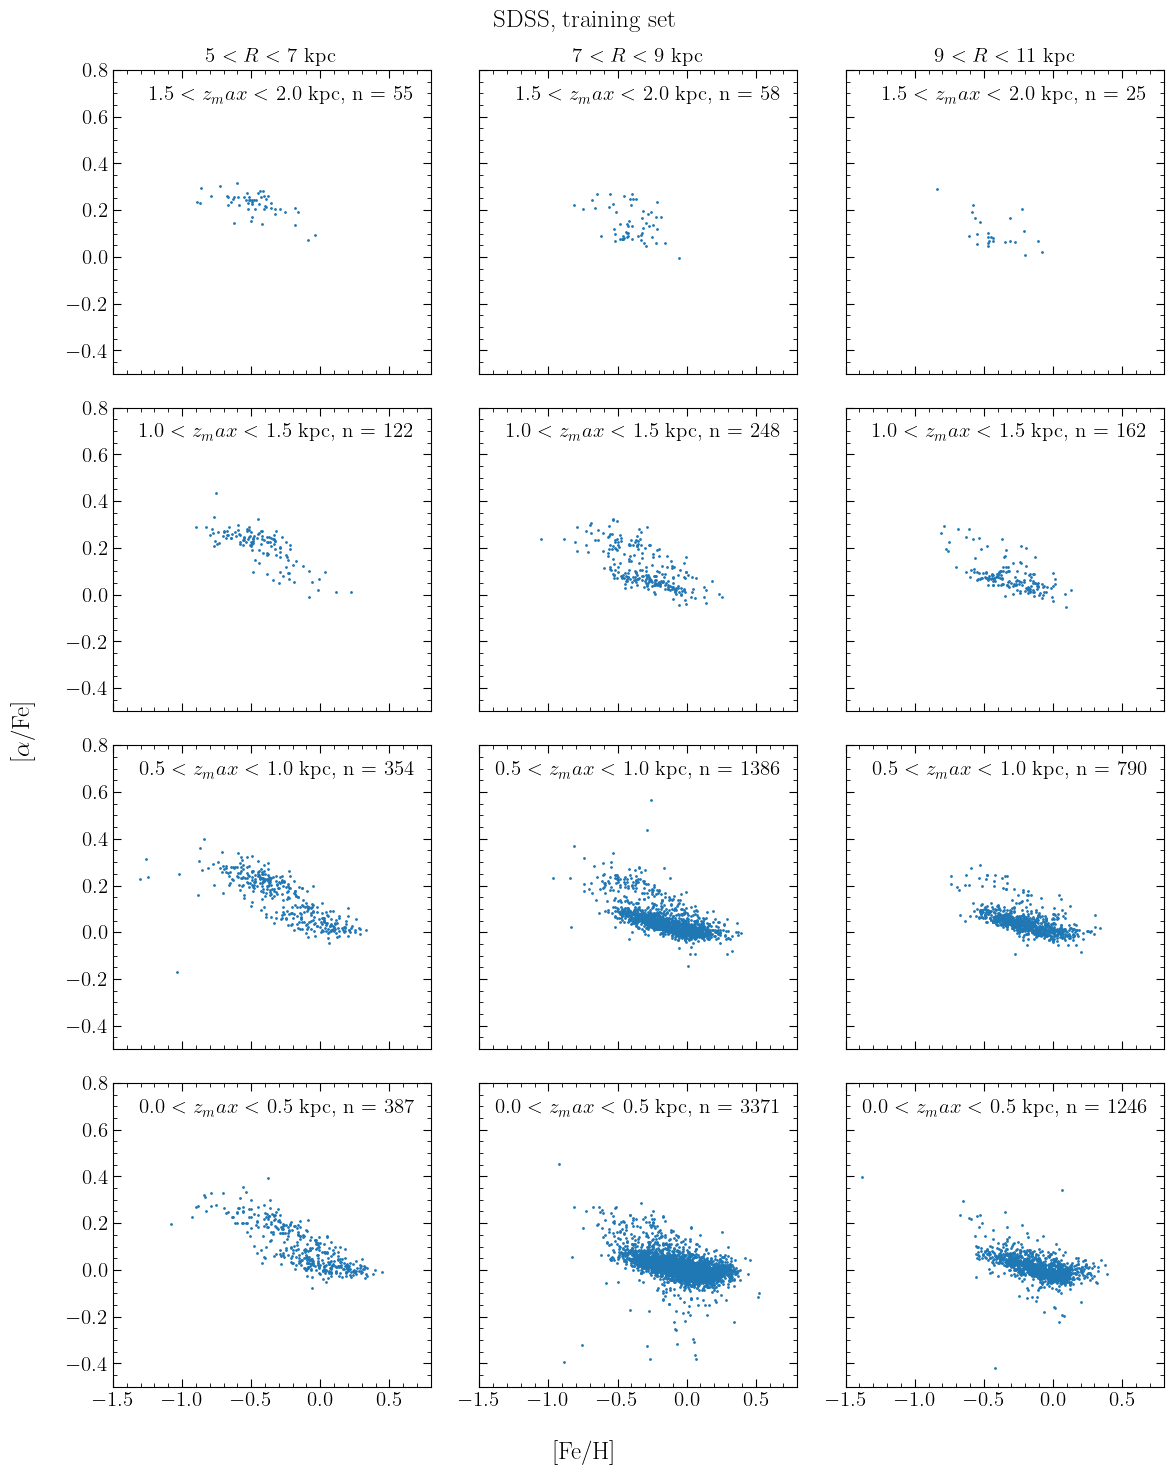

In [78]:
# 1. Define the bins
r_bins = np.arange(5, 13, 2)            # [0, 4, 8, 12, 16]
z_bins = np.arange(0, 2.5, 0.5)    # [0.0, 0.5, 1.0, 1.5, 2.0]

n_rows = len(z_bins) - 1
n_cols = len(r_bins) - 1

# 2. Set up the matplotlib grid
fig, axes = plt.subplots(
    nrows=n_rows, 
    ncols=n_cols, 
    figsize=(12, 15), 
    sharex=True, 
    sharey=True
)

# 3. Iterate and plot
for i in range(n_rows):
    # Invert row index so Z=0 is at the bottom
    row_idx = n_rows - 1 - i 
    z_min, z_max = z_bins[i], z_bins[i+1]
    
    for j in range(n_cols):
        r_min, r_max = r_bins[j], r_bins[j+1]
        ax = axes[row_idx, j]
        
        # Filter the dataset
        mask = (
            (training_sdss_all['R_guide'] >= r_min) & 
            (training_sdss_all['R_guide'] < r_max) & 
            (training_sdss_all['z_max'] >= z_min) & 
            (training_sdss_all['z_max'] < z_max)
        )
        subset = training_sdss_all[mask]
        
        # Scatter plot for this bin
        ax.scatter(subset['fe_h'], subset['alpha_fe'], s=1, alpha=1, color='tab:blue')
        
        # Format grid titles (R bins on top row)
        if row_idx == 0:  
            ax.set_title(fr'{r_min} $ < R < $ {r_max} kpc')
            
        # z_max text inside every plot (like a legend)
        ax.text(0.95, 0.95, fr'{z_min} $ < z_max < $ {z_max} kpc,  n = {len(subset)}', 
                transform=ax.transAxes, 
                horizontalalignment='right', 
                verticalalignment='top',
                bbox=dict(facecolor='white', alpha=0.8, edgecolor='none'))
        
        ax.set_ylim(-0.5, 0.8)
        ax.set_xlim(-1.5, 0.8)

# 4. Add global labels
fig.supxlabel('[Fe/H]')
fig.supylabel(r'[$\alpha$/Fe]')
fig.suptitle("SDSS, training set")
plt.tight_layout()
plt.show()

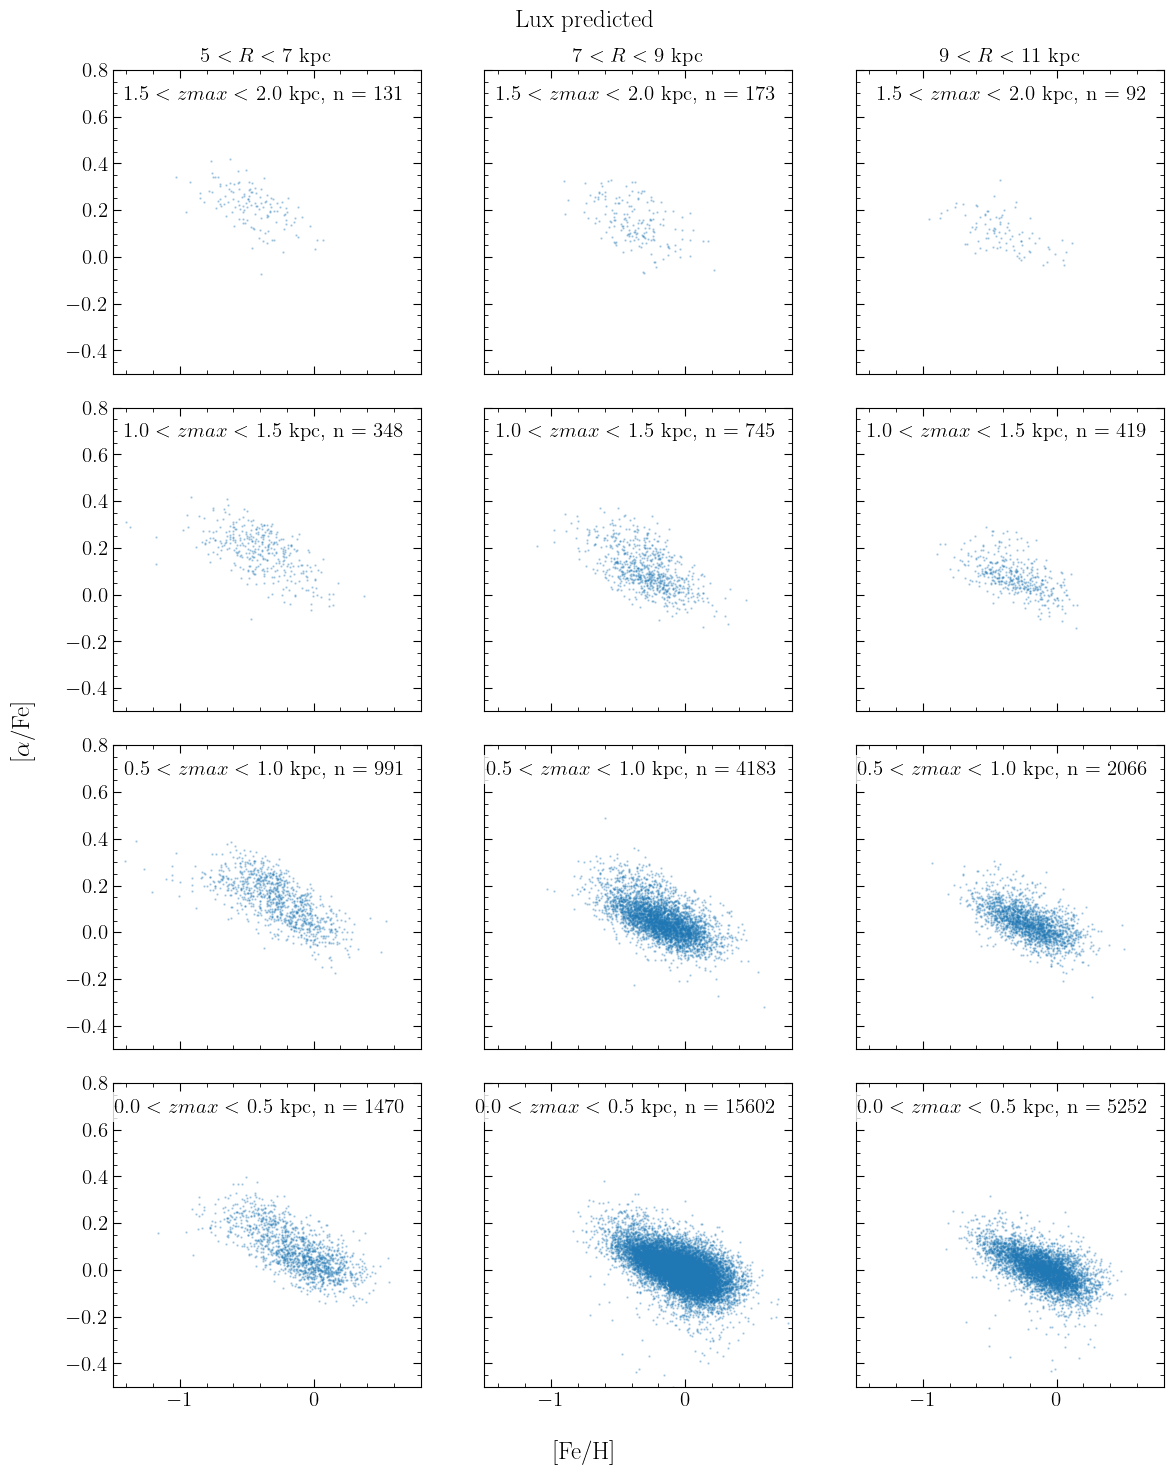

In [79]:
# 1. Define the bins
r_bins = np.arange(5, 13, 2)            # [0, 4, 8, 12, 16]
z_bins = np.arange(0, 2.5, 0.5)    # [0.0, 0.5, 1.0, 1.5, 2.0]

n_rows = len(z_bins) - 1
n_cols = len(r_bins) - 1

# 2. Set up the matplotlib grid
fig, axes = plt.subplots(
    nrows=n_rows, 
    ncols=n_cols, 
    figsize=(12, 15), 
    sharex=True, 
    sharey=True
)

# 3. Iterate and plot
for i in range(n_rows):
    # Invert row index so Z=0 is at the bottom
    row_idx = n_rows - 1 - i 
    z_min, z_max = z_bins[i], z_bins[i+1]
    
    for j in range(n_cols):
        r_min, r_max = r_bins[j], r_bins[j+1]
        ax = axes[row_idx, j]
        
        # Filter the dataset
        mask = (
            (lux_pred_all['R_guide'] >= r_min) & 
            (lux_pred_all['R_guide'] < r_max) & 
            (lux_pred_all['z_max'] >= z_min) & 
            (lux_pred_all['z_max'] < z_max)
        )
        subset = lux_pred_all[mask]
        
        # Scatter plot for this bin
        ax.scatter(subset['fe_h'], subset['alpha_fe'], s=0.5, alpha=0.3, color='tab:blue')
        
        # Format grid titles (R bins on top row)
        if row_idx == 0:  
            ax.set_title(fr'{r_min} $ < R < $ {r_max} kpc')
            
        # z_max text inside every plot (like a legend)
        ax.text(0.95, 0.95, fr'{z_min} $ < zmax < $ {z_max} kpc,  n = {len(subset)}', 
                transform=ax.transAxes, 
                horizontalalignment='right', 
                verticalalignment='top',
                bbox=dict(facecolor='white', alpha=0.8, edgecolor='none'))
        
        ax.set_ylim(-0.5, 0.8)
        ax.set_xlim(-1.5, 0.8)

# 4. Add global labels
fig.supxlabel('[Fe/H]')
fig.supylabel(r'[$\alpha$/Fe]')
fig.suptitle("Lux predicted")
plt.tight_layout()
plt.show()

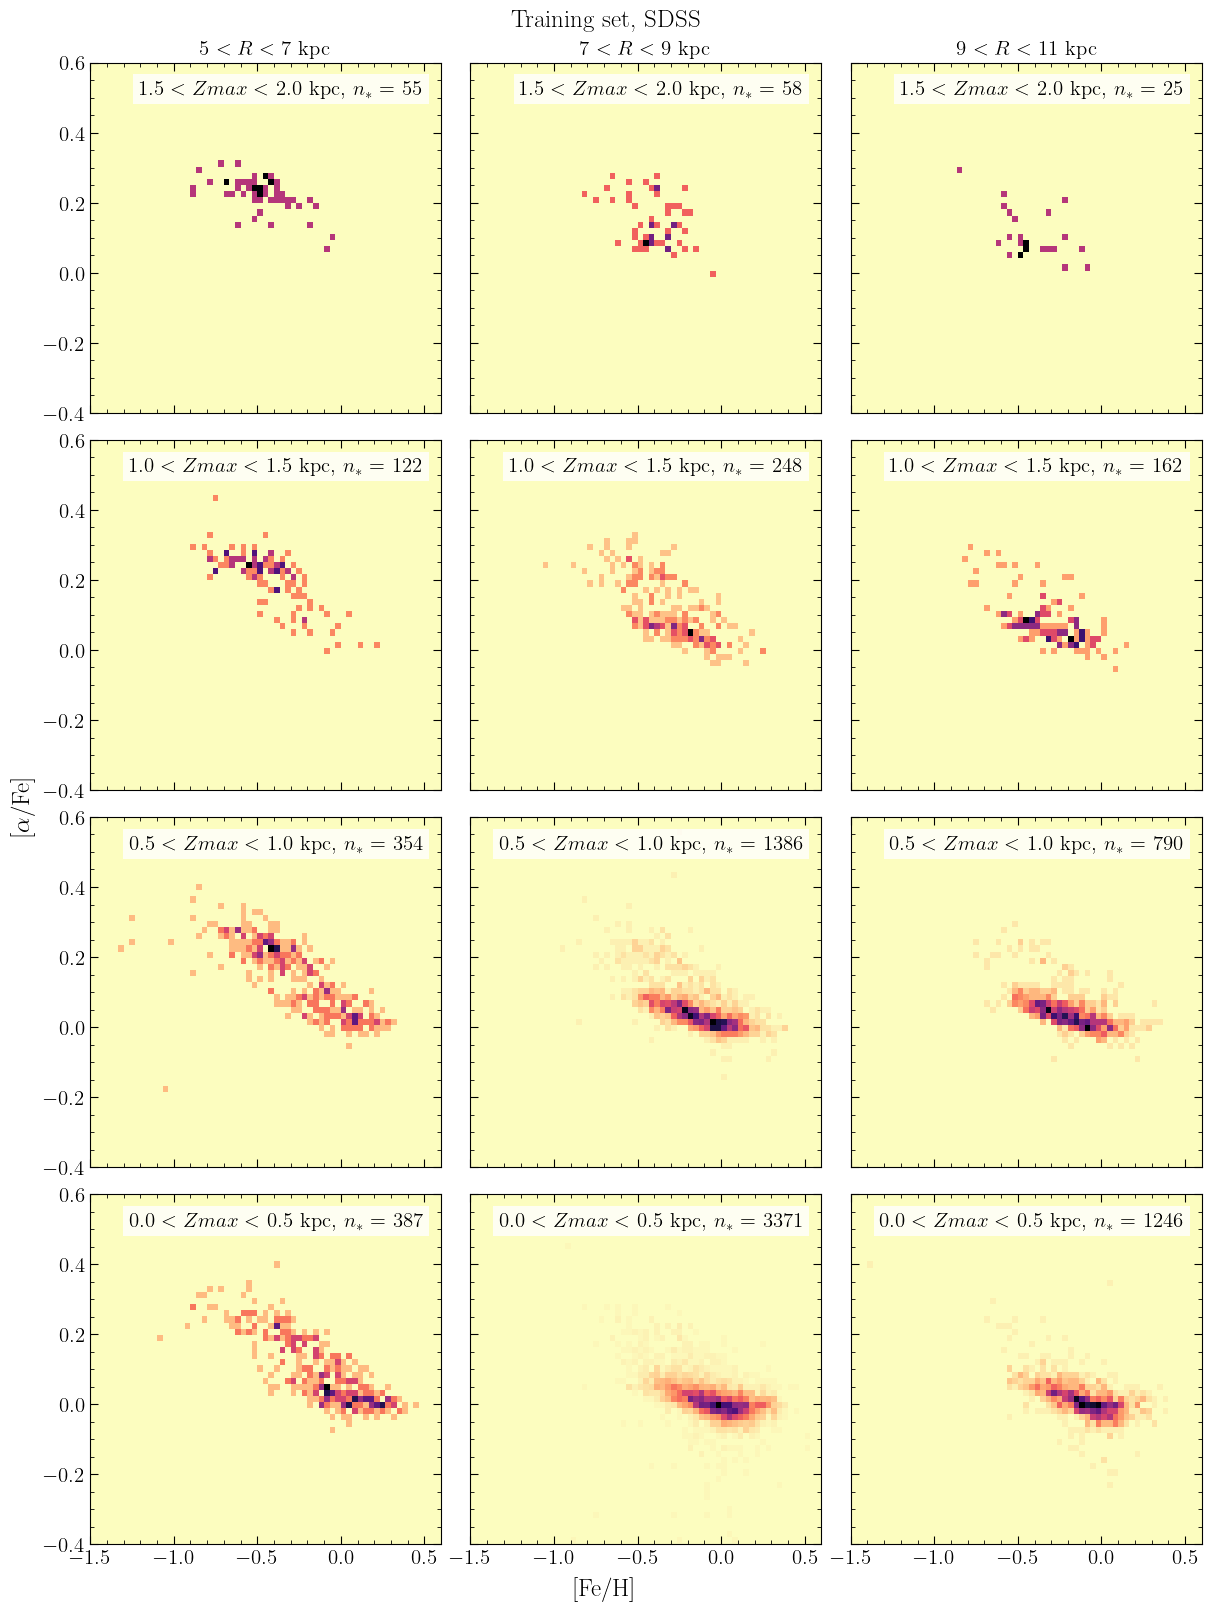

In [43]:
# 1. Define the spatial bins
r_bins = np.arange(5, 13, 2)       
z_bins = np.arange(0, 2.5, 0.5)    # [0.0, 0.5, 1.0, 1.5, 2.0]

n_rows = len(z_bins) - 1
n_cols = len(r_bins) - 1

# 2. Set up the matplotlib grid (using layout="constrained" from your first example)
fig, axes = plt.subplots(
    nrows=n_rows, 
    ncols=n_cols, 
    figsize=(12, 16), 
    sharex=True, 
    sharey=True,
    layout="constrained"
)

# Define 2D histogram bins to match your desired axis limits
feh_bins = np.linspace(-1.5, 0.6, 64)
alpha_bins = np.linspace(-0.5, 0.6, 64)

# 3. Iterate and plot
for i in range(n_rows):
    # Invert row index so Z=0 is at the bottom
    row_idx = n_rows - 1 - i 
    z_min, z_max = z_bins[i], z_bins[i+1]
    
    for j in range(n_cols):
        r_min, r_max = r_bins[j], r_bins[j+1]
        ax = axes[row_idx, j]
        
        # Filter the dataset
        mask = (
            (training_sdss_all['R_guide'] >= r_min) & 
            (training_sdss_all['R_guide'] < r_max) & 
            (training_sdss_all['z_max'] >= z_min) & 
            (training_sdss_all['z_max'] < z_max)
        )
        subset = training_sdss_all[mask]
        
        # 2D Histogram plot
        if len(subset) > 0: # Prevent errors if a bin has 0 stars
            ax.hist2d(
                subset['fe_h'], 
                subset['alpha_fe'], 
                bins=(feh_bins, alpha_bins), 
                cmap="magma_r",
            )
        
        # Format grid titles (R bins on top row)
        if row_idx == 0:  
            ax.set_title(fr'{r_min} $ < R < $ {r_max} kpc')
            
        # Zmax text inside every plot
        ax.text(0.95, 0.95, fr'{z_min} $ < Zmax < $ {z_max} kpc,  $n_*$ = {len(subset)}', 
                transform=ax.transAxes, 
                horizontalalignment='right', 
                verticalalignment='top',
                bbox=dict(facecolor='white', alpha=0.8, edgecolor='none'))
        
        ax.set_ylim(-0.4, 0.6)
        ax.set_xlim(-1.5, 0.6)

# 4. Add global labels
fig.supxlabel('[Fe/H]')
fig.supylabel(r'[$\alpha$/Fe]')
fig.suptitle("Training set, SDSS")
plt.show()

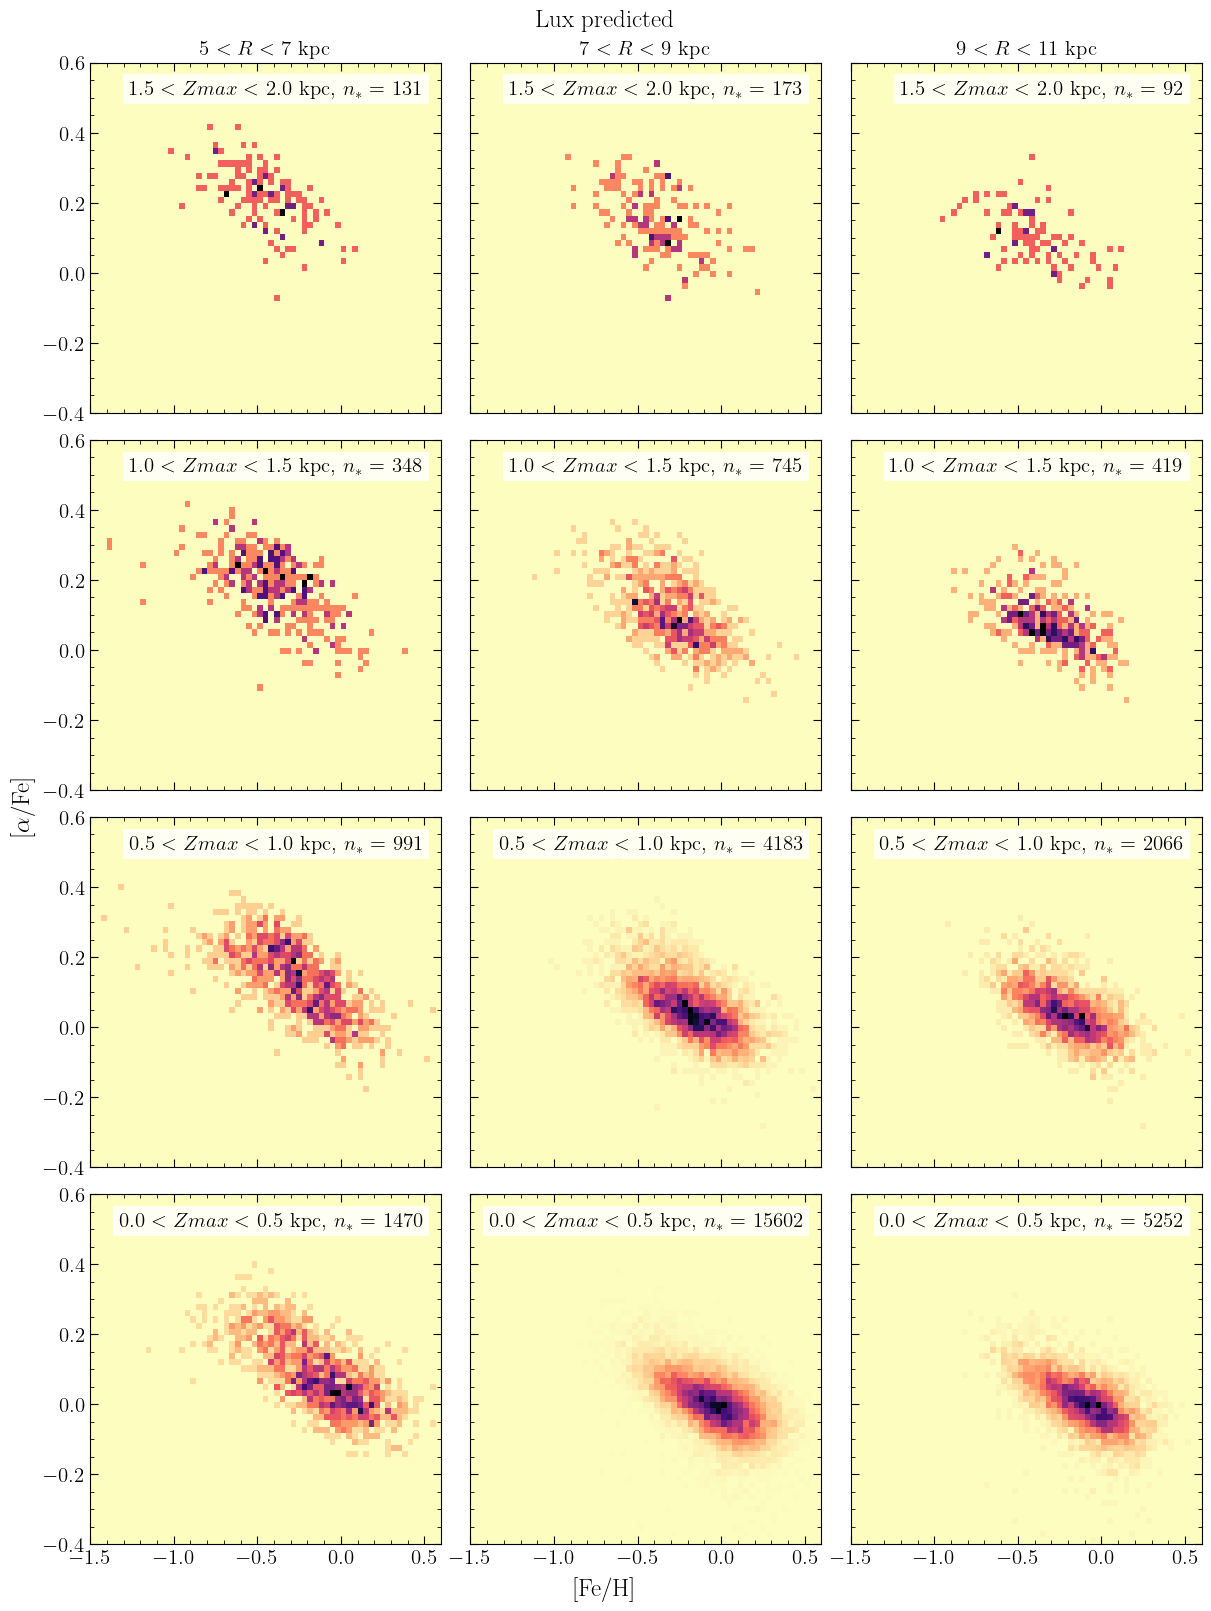

In [45]:
# 1. Define the spatial bins
r_bins = np.arange(5, 13, 2)       
z_bins = np.arange(0, 2.5, 0.5)    # [0.0, 0.5, 1.0, 1.5, 2.0]

n_rows = len(z_bins) - 1
n_cols = len(r_bins) - 1

# 2. Set up the matplotlib grid (using layout="constrained" from your first example)
fig, axes = plt.subplots(
    nrows=n_rows, 
    ncols=n_cols, 
    figsize=(12, 16), 
    sharex=True, 
    sharey=True,
    layout="constrained"
)

# Define 2D histogram bins to match your desired axis limits
feh_bins = np.linspace(-1.5, 0.6, 64)
alpha_bins = np.linspace(-0.5, 0.6, 64)

# 3. Iterate and plot
for i in range(n_rows):
    # Invert row index so Z=0 is at the bottom
    row_idx = n_rows - 1 - i 
    z_min, z_max = z_bins[i], z_bins[i+1]
    
    for j in range(n_cols):
        r_min, r_max = r_bins[j], r_bins[j+1]
        ax = axes[row_idx, j]
        
        # Filter the dataset
        mask = (
            (lux_pred_all['R_guide'] >= r_min) & 
            (lux_pred_all['R_guide'] < r_max) & 
            (lux_pred_all['z_max'] >= z_min) & 
            (lux_pred_all['z_max'] < z_max)
        )
        subset = lux_pred_all[mask]
        
        # 2D Histogram plot
        if len(subset) > 0: # Prevent errors if a bin has 0 stars
            ax.hist2d(
                subset['fe_h'], 
                subset['alpha_fe'], 
                bins=(feh_bins, alpha_bins), 
                cmap="magma_r",
            )
        
        # Format grid titles (R bins on top row)
        if row_idx == 0:  
            ax.set_title(fr'{r_min} $ < R < $ {r_max} kpc')
            
        # Zmax text inside every plot
        ax.text(0.95, 0.95, fr'{z_min} $ < Zmax < $ {z_max} kpc,  $n_*$ = {len(subset)}', 
                transform=ax.transAxes, 
                horizontalalignment='right', 
                verticalalignment='top',
                bbox=dict(facecolor='white', alpha=0.8, edgecolor='none'))
        
        ax.set_ylim(-0.4, 0.6)
        ax.set_xlim(-1.5, 0.6)

# 4. Add global labels
fig.supxlabel('[Fe/H]')
fig.supylabel(r'[$\alpha$/Fe]')
fig.suptitle("Lux predicted")
plt.show()

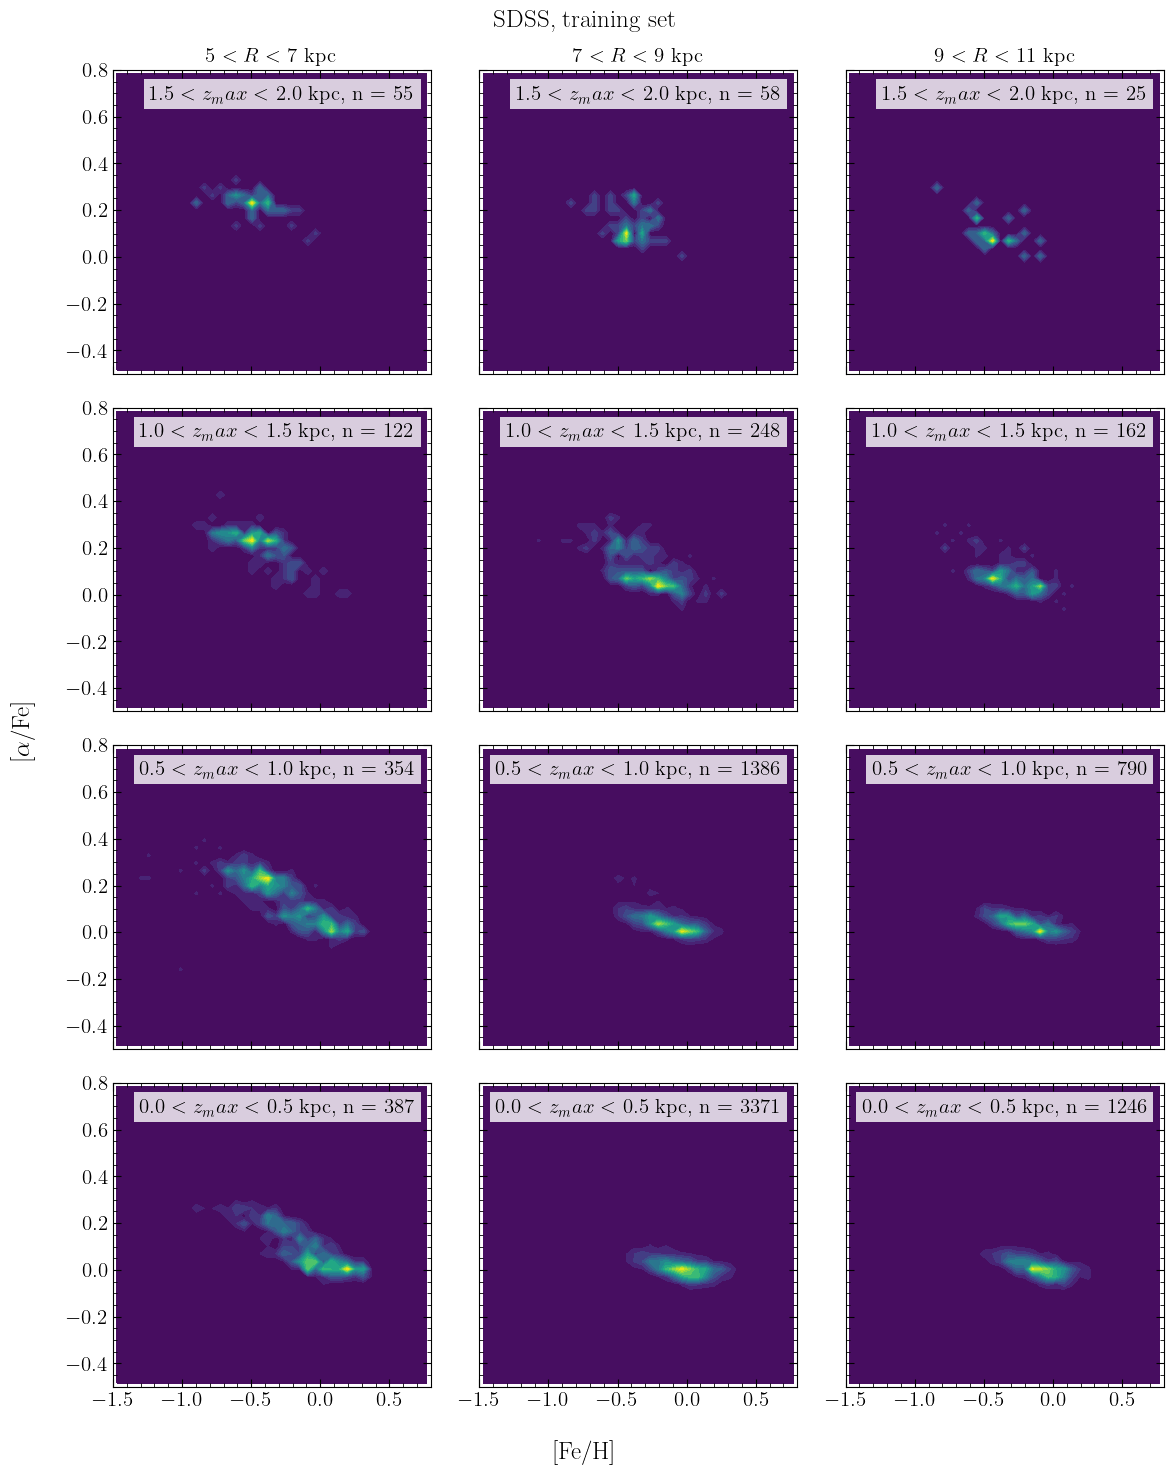

In [81]:
import numpy as np
import matplotlib.pyplot as plt

# 1. Define the bins
r_bins = np.arange(5, 13, 2)       
z_bins = np.arange(0, 2.5, 0.5)    

n_rows = len(z_bins) - 1
n_cols = len(r_bins) - 1

# 2. Set up the matplotlib grid
fig, axes = plt.subplots(
    nrows=n_rows, 
    ncols=n_cols, 
    figsize=(12, 15), 
    sharex=True, 
    sharey=True
)

# 3. Iterate and plot
for i in range(n_rows):
    # Invert row index so Z=0 is at the bottom
    row_idx = n_rows - 1 - i 
    z_min = z_bins[i]
    z_max = z_bins[i+1]
    
    for j in range(n_cols):
        r_min = r_bins[j]
        r_max = r_bins[j+1]
        ax = axes[row_idx, j]
        
        # Filter the dataset
        mask_r = (training_sdss_all['R_guide'] >= r_min) & (training_sdss_all['R_guide'] < r_max)
        mask_z = (training_sdss_all['z_max'] >= z_min) & (training_sdss_all['z_max'] < z_max)
        mask = mask_r & mask_z
        subset = training_sdss_all[mask]
        
        # Create density contours if the bin is not empty
        if len(subset) > 0:
            x = subset['fe_h']
            y = subset['alpha_fe']
            
            # Calculate 2D density histogram
            counts, x_edges, y_edges = np.histogram2d(
                x, y, 
                bins=40, 
                range=[[-1.5, 0.8], [-0.5, 0.8]]
            )
            
            # Find the center of each bin to plot the contours
            x_centers = (x_edges[:-1] + x_edges[1:]) / 2
            y_centers = (y_edges[:-1] + y_edges[1:]) / 2
            
            # Plot the filled contours using viridis
            ax.contourf(x_centers, y_centers, counts.T, levels=15, cmap='viridis')
        
        # Format grid titles (R bins on top row)
        if row_idx == 0:  
            ax.set_title(fr'{r_min} $ < R < $ {r_max} kpc')
            
        # z_max text inside every plot 
        ax.text(0.95, 0.95, fr'{z_min} $ < z_max < $ {z_max} kpc,  n = {len(subset)}', 
                transform=ax.transAxes, 
                horizontalalignment='right', 
                verticalalignment='top',
                bbox=dict(facecolor='white', alpha=0.8, edgecolor='none'))
        
        ax.set_ylim(-0.5, 0.8)
        ax.set_xlim(-1.5, 0.8)

# 4. Add global labels
fig.supxlabel('[Fe/H]')
fig.supylabel(r'[$\alpha$/Fe]')
fig.suptitle("SDSS, training set")
plt.tight_layout()
plt.show()

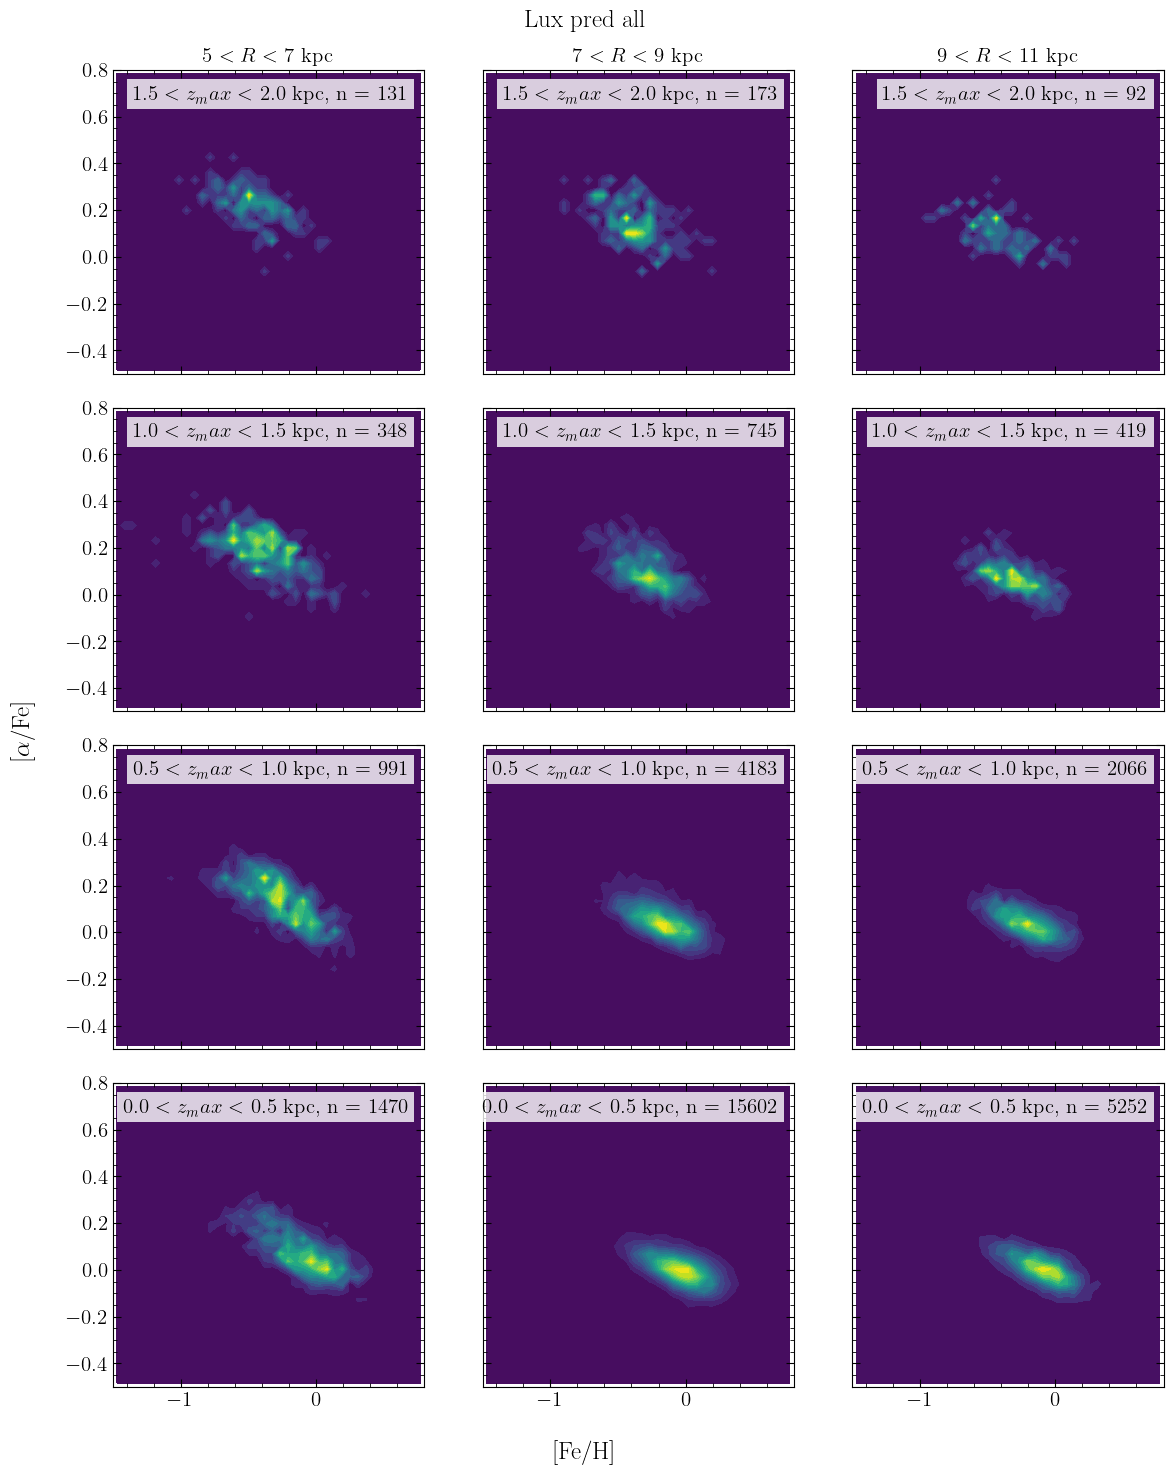

In [80]:
# 1. Define the bins
r_bins = np.arange(5, 13, 2)       
z_bins = np.arange(0, 2.5, 0.5)    

n_rows = len(z_bins) - 1
n_cols = len(r_bins) - 1

# 2. Set up the matplotlib grid
fig, axes = plt.subplots(
    nrows=n_rows, 
    ncols=n_cols, 
    figsize=(12, 15), 
    sharex=True, 
    sharey=True
)

# 3. Iterate and plot
for i in range(n_rows):
    # Invert row index so Z=0 is at the bottom
    row_idx = n_rows - 1 - i 
    z_min = z_bins[i]
    z_max = z_bins[i+1]
    
    for j in range(n_cols):
        r_min = r_bins[j]
        r_max = r_bins[j+1]
        ax = axes[row_idx, j]
        
        # Filter the dataset
        mask_r = (lux_pred_all['R_guide'] >= r_min) & (lux_pred_all['R_guide'] < r_max)
        mask_z = (lux_pred_all['z_max'] >= z_min) & (lux_pred_all['z_max'] < z_max)
        mask = mask_r & mask_z
        subset = lux_pred_all[mask]
        
        # Create density contours if the bin is not empty
        if len(subset) > 0:
            x = subset['fe_h']
            y = subset['alpha_fe']
            
            # Calculate 2D density histogram
            counts, x_edges, y_edges = np.histogram2d(
                x, y, 
                bins=40, 
                range=[[-1.5, 0.8], [-0.5, 0.8]]
            )
            
            # Find the center of each bin to plot the contours
            x_centers = (x_edges[:-1] + x_edges[1:]) / 2
            y_centers = (y_edges[:-1] + y_edges[1:]) / 2
            
            # Plot the filled contours using viridis
            ax.contourf(x_centers, y_centers, counts.T, levels=15, cmap='viridis')
        
        # Format grid titles (R bins on top row)
        if row_idx == 0:  
            ax.set_title(fr'{r_min} $ < R < $ {r_max} kpc')
            
        # z_max text inside every plot 
        ax.text(0.95, 0.95, fr'{z_min} $ < z_max < $ {z_max} kpc,  n = {len(subset)}', 
                transform=ax.transAxes, 
                horizontalalignment='right', 
                verticalalignment='top',
                bbox=dict(facecolor='white', alpha=0.8, edgecolor='none'))
        
        ax.set_ylim(-0.5, 0.8)
        ax.set_xlim(-1.5, 0.8)

# 4. Add global labels
fig.supxlabel('[Fe/H]')
fig.supylabel(r'[$\alpha$/Fe]')
fig.suptitle("Lux pred all")
plt.tight_layout()
plt.show()

# Playing with colors

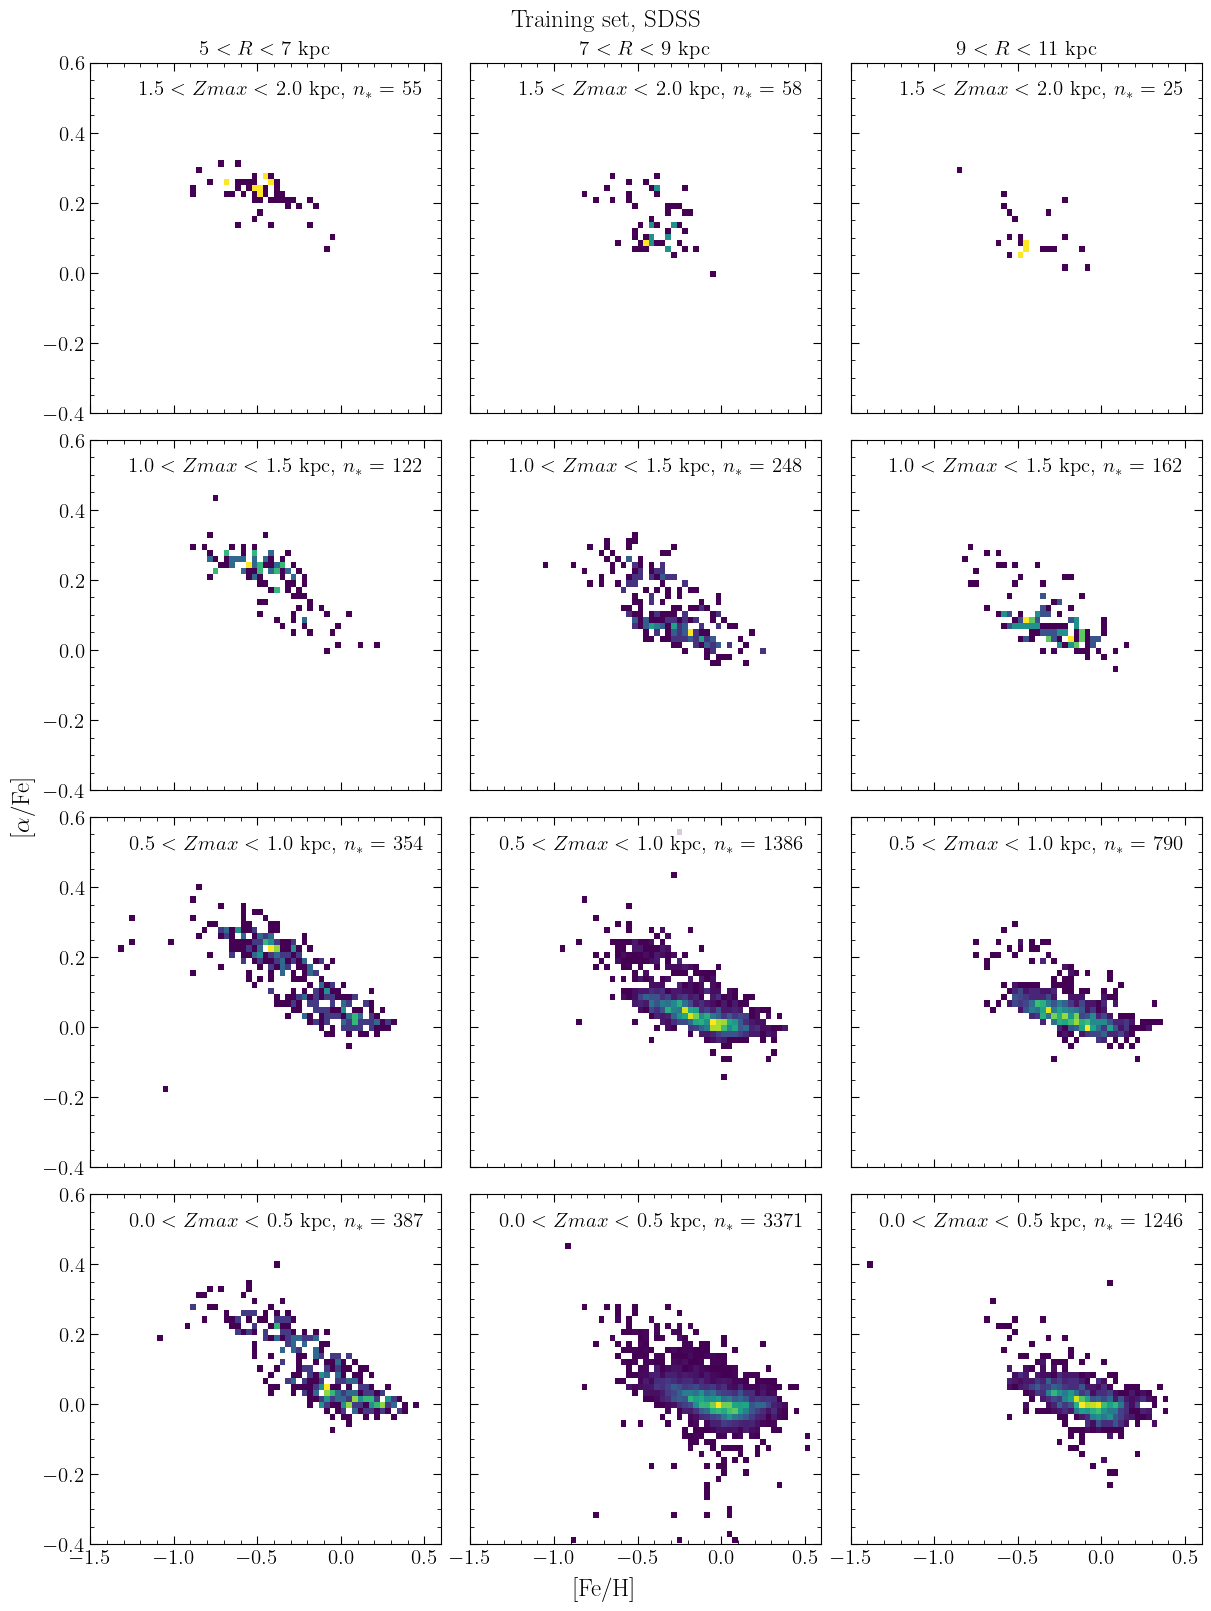

In [48]:
# 1. Define the spatial bins
r_bins = np.arange(5, 13, 2)       
z_bins = np.arange(0, 2.5, 0.5)    # [0.0, 0.5, 1.0, 1.5, 2.0]

n_rows = len(z_bins) - 1
n_cols = len(r_bins) - 1

# 2. Set up the matplotlib grid (using layout="constrained" from your first example)
fig, axes = plt.subplots(
    nrows=n_rows, 
    ncols=n_cols, 
    figsize=(12, 16), 
    sharex=True, 
    sharey=True,
    layout="constrained"
)

# Define 2D histogram bins to match your desired axis limits
feh_bins = np.linspace(-1.5, 0.6, 64)
alpha_bins = np.linspace(-0.5, 0.6, 64)

# 3. Iterate and plot
for i in range(n_rows):
    # Invert row index so Z=0 is at the bottom
    row_idx = n_rows - 1 - i 
    z_min, z_max = z_bins[i], z_bins[i+1]
    
    for j in range(n_cols):
        r_min, r_max = r_bins[j], r_bins[j+1]
        ax = axes[row_idx, j]
        
        # Filter the dataset
        mask = (
            (training_sdss_all['R_guide'] >= r_min) & 
            (training_sdss_all['R_guide'] < r_max) & 
            (training_sdss_all['z_max'] >= z_min) & 
            (training_sdss_all['z_max'] < z_max)
        )
        subset = training_sdss_all[mask]
        
        # 2D Histogram plot
        if len(subset) > 0: # Prevent errors if a bin has 0 stars
            ax.hist2d(
                subset['fe_h'], 
                subset['alpha_fe'], 
                bins=(feh_bins, alpha_bins), 
                cmap="viridis",
                cmin = 1
            )
        
        # Format grid titles (R bins on top row)
        if row_idx == 0:  
            ax.set_title(fr'{r_min} $ < R < $ {r_max} kpc')
            
        # Zmax text inside every plot
        ax.text(0.95, 0.95, fr'{z_min} $ < Zmax < $ {z_max} kpc,  $n_*$ = {len(subset)}', 
                transform=ax.transAxes, 
                horizontalalignment='right', 
                verticalalignment='top',
                bbox=dict(facecolor='white', alpha=0.8, edgecolor='none'))
        
        ax.set_ylim(-0.4, 0.6)
        ax.set_xlim(-1.5, 0.6)

# 4. Add global labels
fig.supxlabel('[Fe/H]')
fig.supylabel(r'[$\alpha$/Fe]')
fig.suptitle("Training set, SDSS")
plt.show()

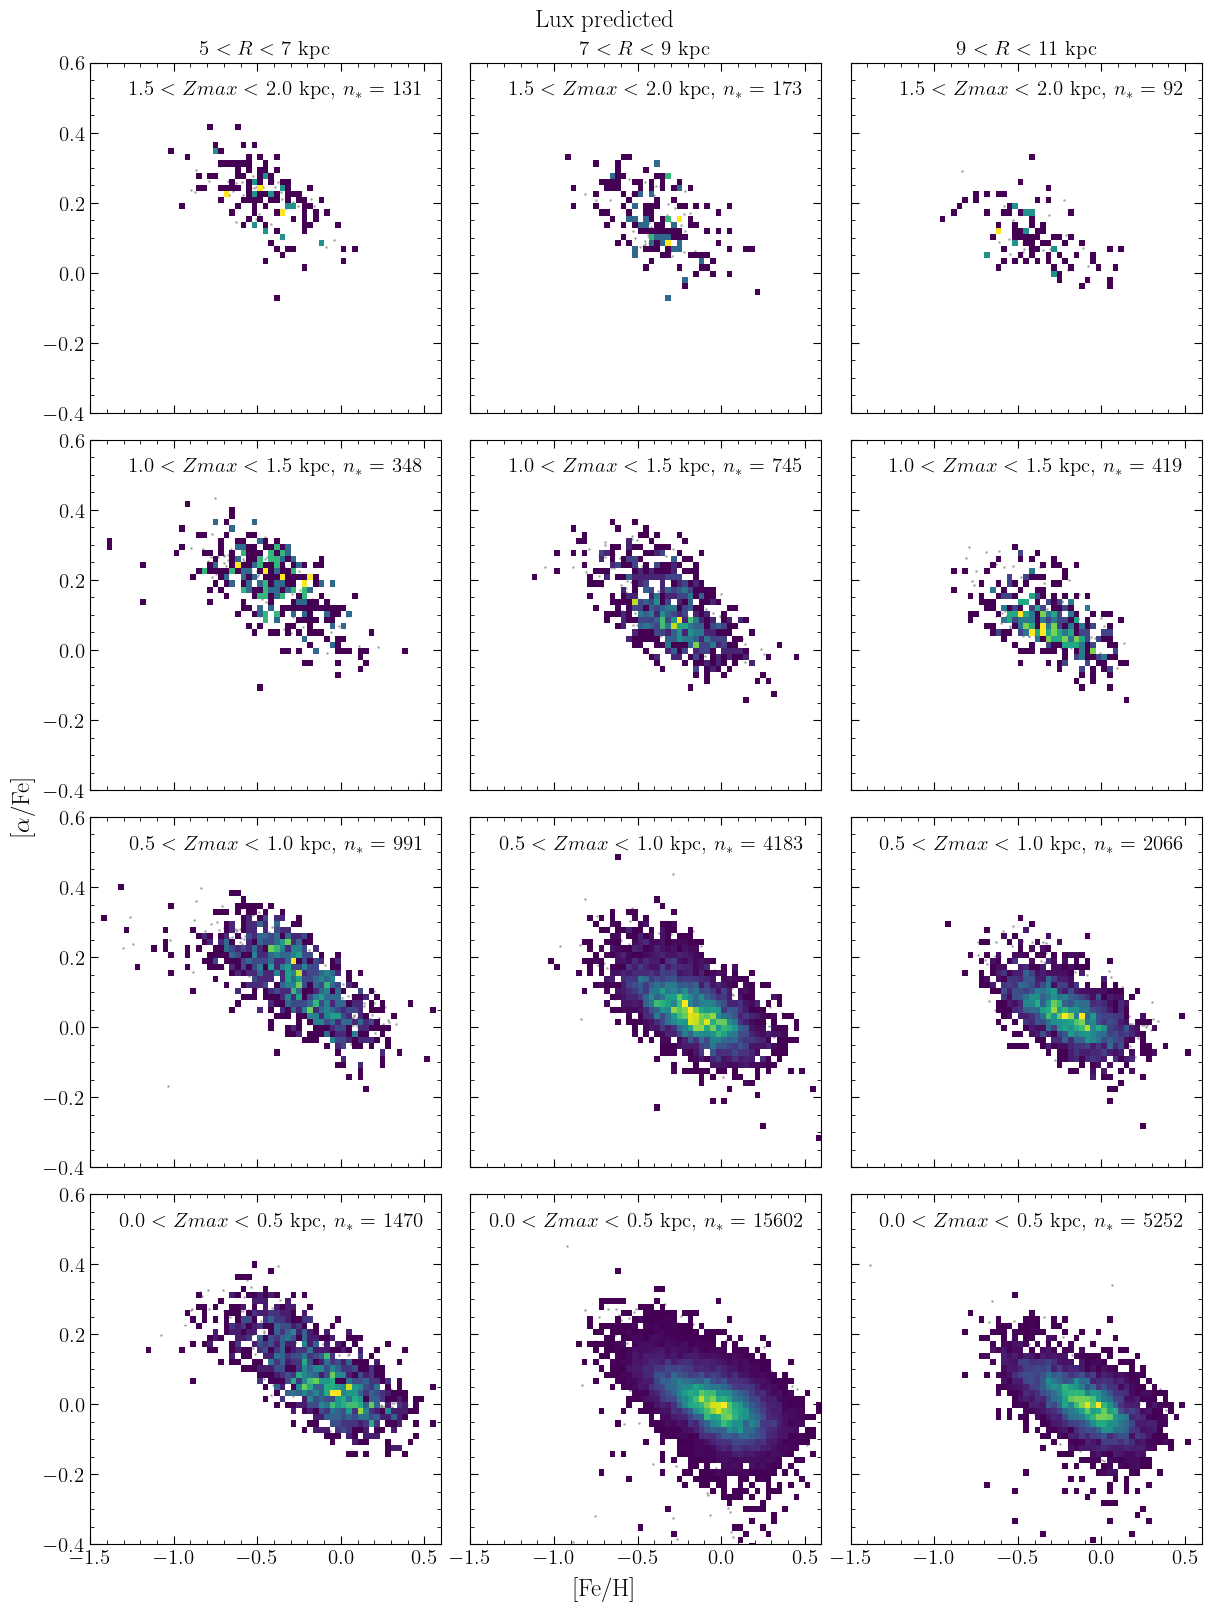

In [57]:
# 1. Define the spatial bins
r_bins = np.arange(5, 13, 2)       
z_bins = np.arange(0, 2.5, 0.5)    # [0.0, 0.5, 1.0, 1.5, 2.0]

n_rows = len(z_bins) - 1
n_cols = len(r_bins) - 1

# 2. Set up the matplotlib grid (using layout="constrained" from your first example)
fig, axes = plt.subplots(
    nrows=n_rows, 
    ncols=n_cols, 
    figsize=(12, 16), 
    sharex=True, 
    sharey=True,
    layout="constrained"
)

# Define 2D histogram bins to match your desired axis limits
feh_bins = np.linspace(-1.5, 0.6, 64)
alpha_bins = np.linspace(-0.5, 0.6, 64)

# 3. Iterate and plot
for i in range(n_rows):
    # Invert row index so Z=0 is at the bottom
    row_idx = n_rows - 1 - i 
    z_min, z_max = z_bins[i], z_bins[i+1]
    
    for j in range(n_cols):
        r_min, r_max = r_bins[j], r_bins[j+1]
        ax = axes[row_idx, j]
        
        # Filter the dataset
        mask = (
            (lux_pred_all['R_guide'] >= r_min) & 
            (lux_pred_all['R_guide'] < r_max) & 
            (lux_pred_all['z_max'] >= z_min) & 
            (lux_pred_all['z_max'] < z_max)
        )

        mask_sdss = ((training_sdss_all['R_guide'] >= r_min) & 
                    (training_sdss_all['R_guide'] < r_max) & 
                    (training_sdss_all['z_max'] >= z_min) & 
                    (training_sdss_all['z_max'] < z_max))
        subset = lux_pred_all[mask]
        subset_sdss = training_sdss_all[mask_sdss]
        
        ax.scatter(subset_sdss['fe_h'], subset_sdss['alpha_fe'], color = 'gray', s = 1, alpha = 0.5)
        # 2D Histogram plot
        if len(subset) > 0: # Prevent errors if a bin has 0 stars
            ax.hist2d(
                subset['fe_h'], 
                subset['alpha_fe'], 
                bins=(feh_bins, alpha_bins), 
                cmap="viridis",
                cmin = 1,
                zorder=5
            )

        
        # Format grid titles (R bins on top row)
        if row_idx == 0:  
            ax.set_title(fr'{r_min} $ < R < $ {r_max} kpc')
            
        # Zmax text inside every plot
        ax.text(0.95, 0.95, fr'{z_min} $ < Zmax < $ {z_max} kpc,  $n_*$ = {len(subset)}', 
                transform=ax.transAxes, 
                horizontalalignment='right', 
                verticalalignment='top',
                bbox=dict(facecolor='white', alpha=0.8, edgecolor='none'))
        
        ax.set_ylim(-0.4, 0.6)
        ax.set_xlim(-1.5, 0.6)

# 4. Add global labels
fig.supxlabel('[Fe/H]')
fig.supylabel(r'[$\alpha$/Fe]')
fig.suptitle("Lux predicted")
plt.show()

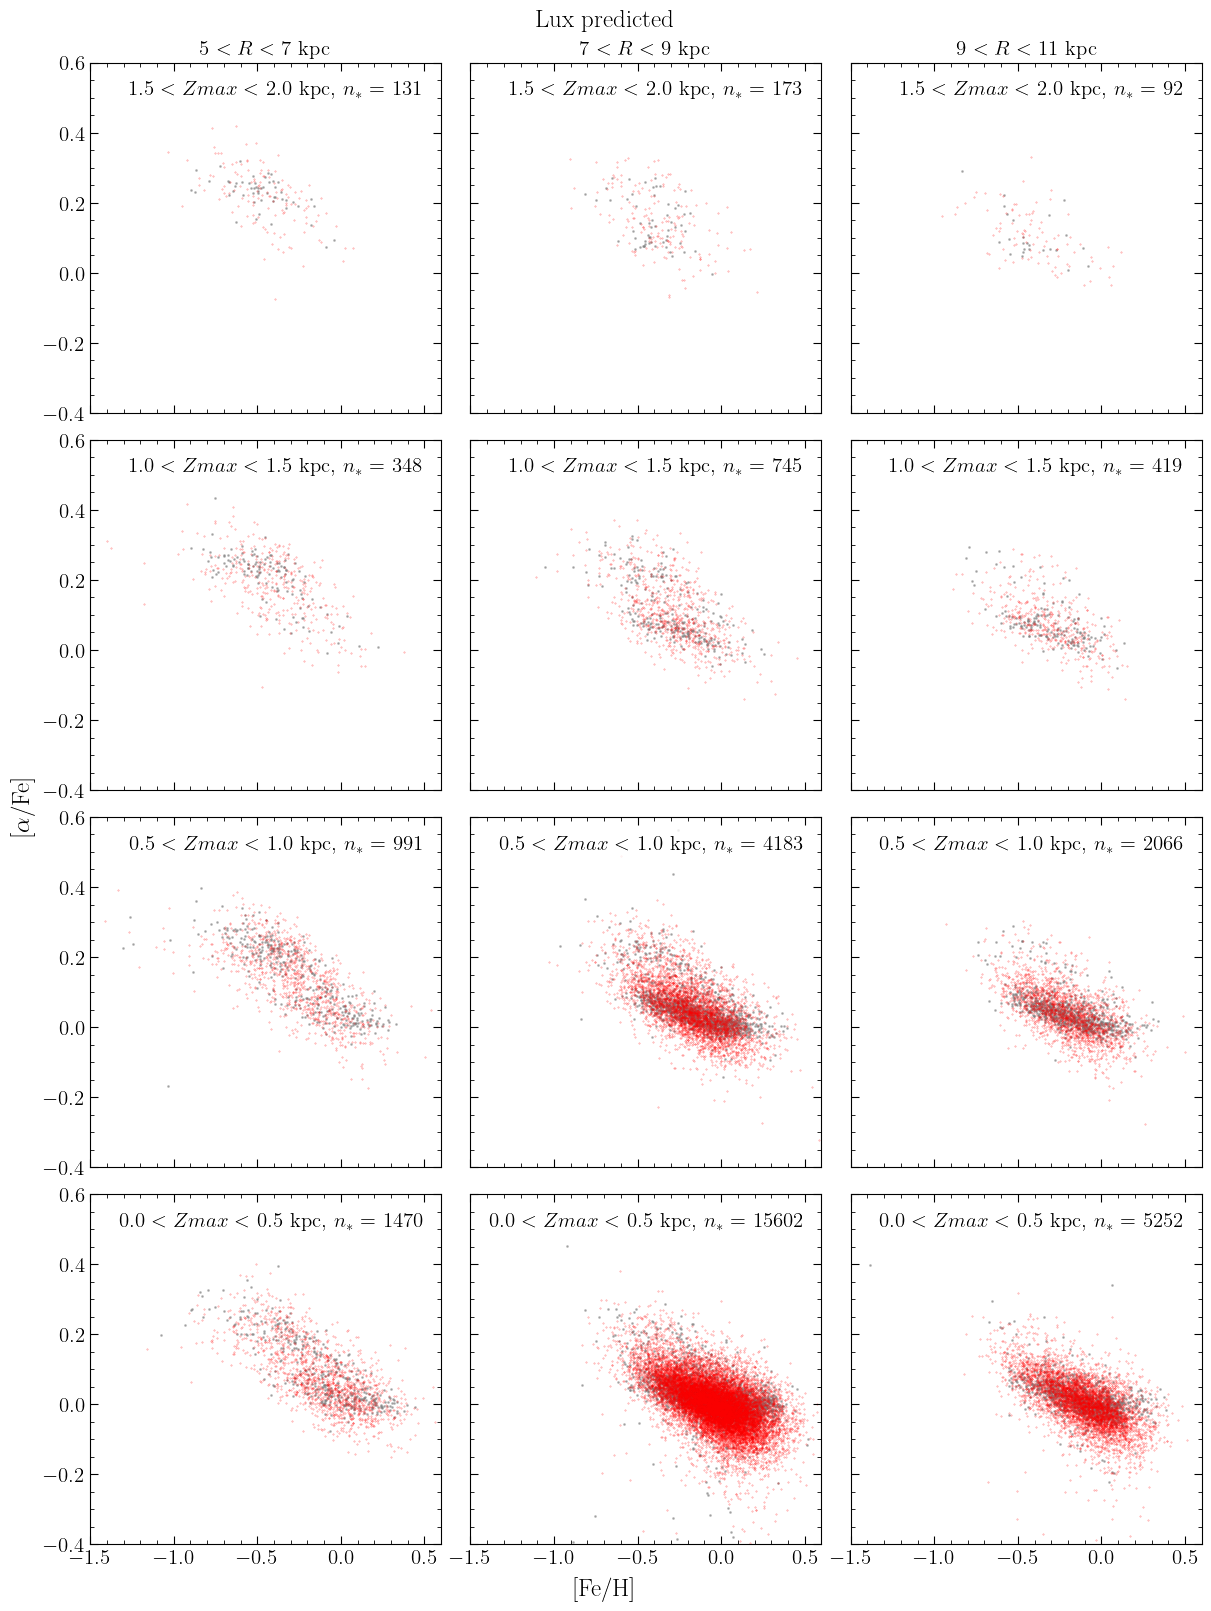

In [60]:
# 1. Define the spatial bins
r_bins = np.arange(5, 13, 2)       
z_bins = np.arange(0, 2.5, 0.5)    # [0.0, 0.5, 1.0, 1.5, 2.0]

n_rows = len(z_bins) - 1
n_cols = len(r_bins) - 1

# 2. Set up the matplotlib grid (using layout="constrained" from your first example)
fig, axes = plt.subplots(
    nrows=n_rows, 
    ncols=n_cols, 
    figsize=(12, 16), 
    sharex=True, 
    sharey=True,
    layout="constrained"
)

# Define 2D histogram bins to match your desired axis limits
feh_bins = np.linspace(-1.5, 0.6, 64)
alpha_bins = np.linspace(-0.5, 0.6, 64)

# 3. Iterate and plot
for i in range(n_rows):
    # Invert row index so Z=0 is at the bottom
    row_idx = n_rows - 1 - i 
    z_min, z_max = z_bins[i], z_bins[i+1]
    
    for j in range(n_cols):
        r_min, r_max = r_bins[j], r_bins[j+1]
        ax = axes[row_idx, j]
        
        # Filter the dataset
        mask = (
                    (lux_pred_all['R_guide'] >= r_min) & 
                    (lux_pred_all['R_guide'] < r_max) & 
                    (lux_pred_all['z_max'] >= z_min) & 
                    (lux_pred_all['z_max'] < z_max)
                )
        
        mask_sdss = ((training_sdss_all['R_guide'] >= r_min) & 
                            (training_sdss_all['R_guide'] < r_max) & 
                            (training_sdss_all['z_max'] >= z_min) & 
                            (training_sdss_all['z_max'] < z_max))
        subset = lux_pred_all[mask]
        subset_sdss = training_sdss_all[mask_sdss]
        
        ax.scatter(subset_sdss['fe_h'], subset_sdss['alpha_fe'], color = 'gray', s = 1, alpha = 0.5)
        # 2D Histogram plot
        ax.scatter(subset['fe_h'], subset['alpha_fe'], color = 'red', s = 0.1, alpha = 0.5)

        
        # Format grid titles (R bins on top row)
        if row_idx == 0:  
            ax.set_title(fr'{r_min} $ < R < $ {r_max} kpc')
            
        # Zmax text inside every plot
        ax.text(0.95, 0.95, fr'{z_min} $ < Zmax < $ {z_max} kpc,  $n_*$ = {len(subset)}', 
                transform=ax.transAxes, 
                horizontalalignment='right', 
                verticalalignment='top',
                bbox=dict(facecolor='white', alpha=0.8, edgecolor='none'))
        
        ax.set_ylim(-0.4, 0.6)
        ax.set_xlim(-1.5, 0.6)

# 4. Add global labels
fig.supxlabel('[Fe/H]')
fig.supylabel(r'[$\alpha$/Fe]')
fig.suptitle("Lux predicted")
plt.show()

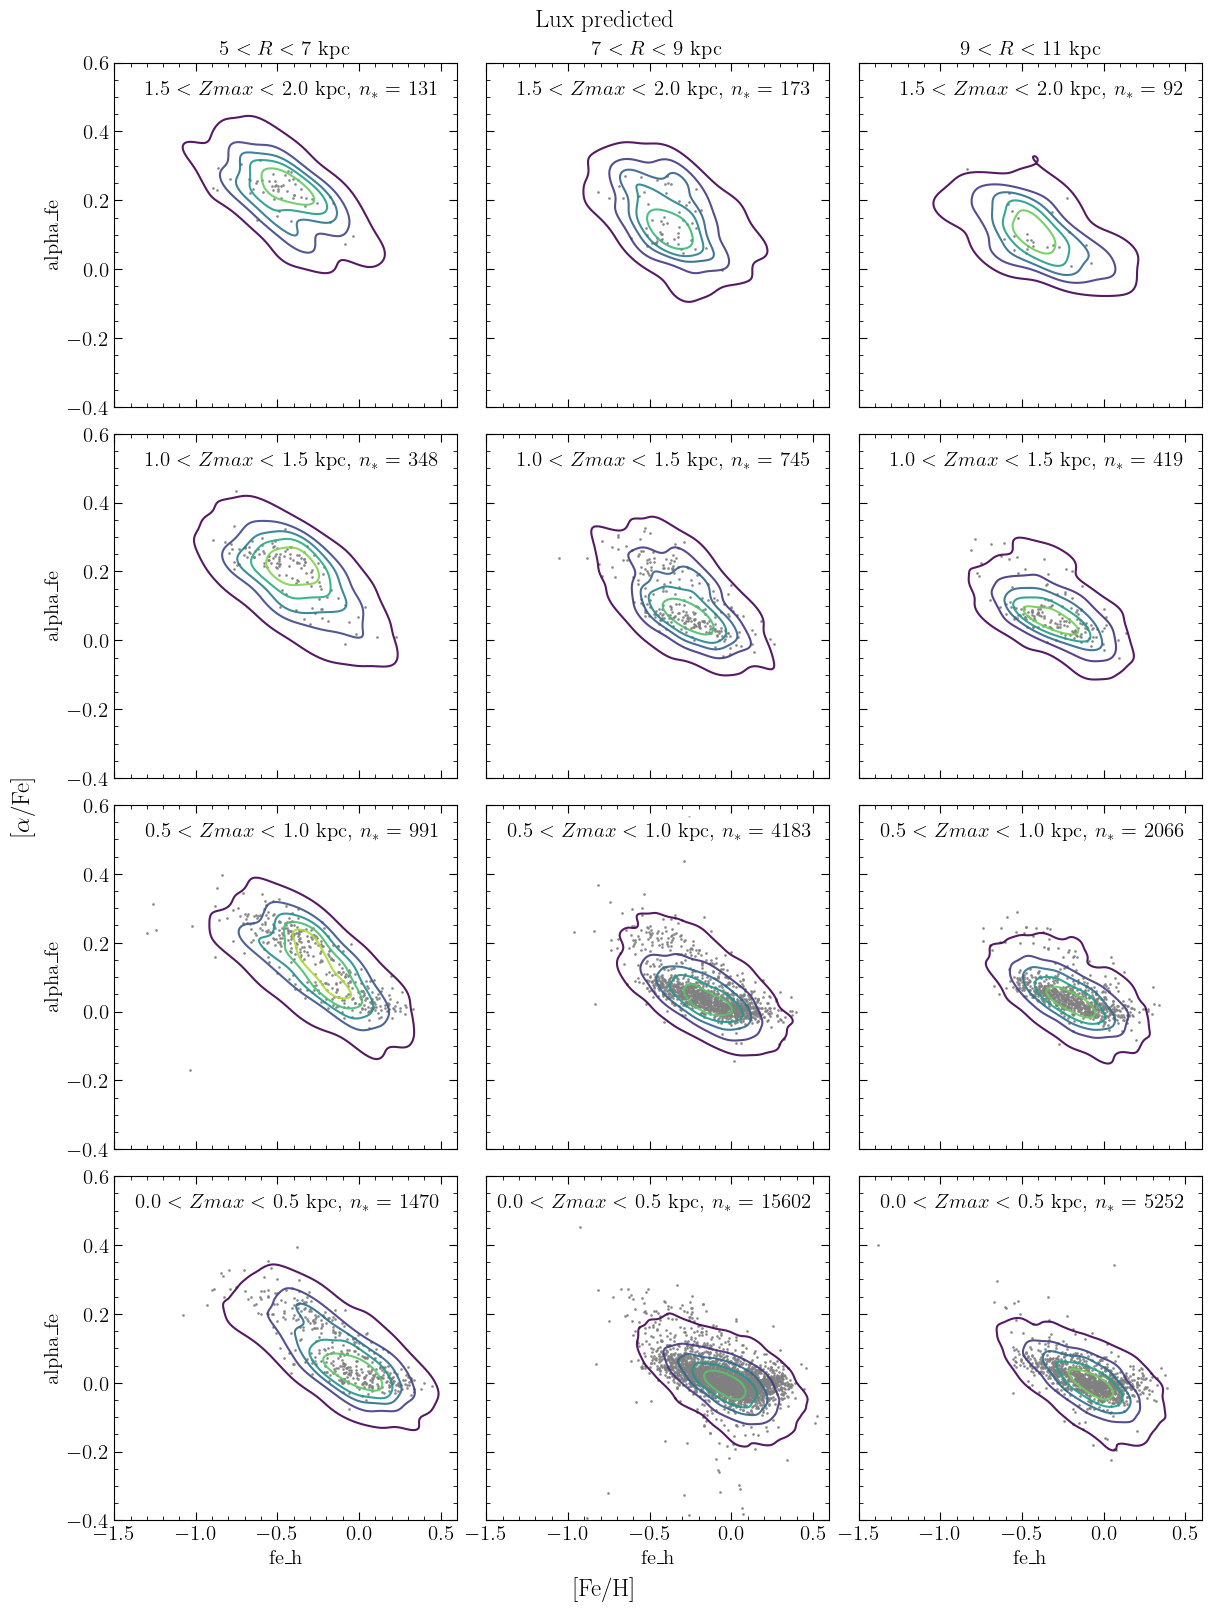

In [62]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Define the spatial bins
r_bins = np.arange(5, 13, 2)       
z_bins = np.arange(0, 2.5, 0.5)    

n_rows = len(z_bins) - 1
n_cols = len(r_bins) - 1

# 2. Set up the matplotlib grid 
fig, axes = plt.subplots(
    nrows=n_rows, 
    ncols=n_cols, 
    figsize=(12, 16), 
    sharex=True, 
    sharey=True,
    layout="constrained"
)

# 3. Iterate and plot
for i in range(n_rows):
    # Invert row index so Z=0 is at the bottom
    row_idx = n_rows - 1 - i 
    z_min, z_max = z_bins[i], z_bins[i+1]
    
    for j in range(n_cols):
        r_min, r_max = r_bins[j], r_bins[j+1]
        ax = axes[row_idx, j]
        
        # Filter the dataset
        mask = (
            (lux_pred_all['R_guide'] >= r_min) & 
            (lux_pred_all['R_guide'] < r_max) & 
            (lux_pred_all['z_max'] >= z_min) & 
            (lux_pred_all['z_max'] < z_max)
        )

        mask_sdss = (
            (training_sdss_all['R_guide'] >= r_min) & 
            (training_sdss_all['R_guide'] < r_max) & 
            (training_sdss_all['z_max'] >= z_min) & 
            (training_sdss_all['z_max'] < z_max)
        )
        
        subset = lux_pred_all[mask]
        subset_sdss = training_sdss_all[mask_sdss]
        
        # Plot background scatter
        if len(subset_sdss) > 0:
            ax.scatter(subset_sdss['fe_h'], subset_sdss['alpha_fe'], color='gray', s=1, alpha=0.8, zorder=1)
        
        # Plot Seaborn KDE contour lines on the current axis
        if len(subset) > 0:
            sns.kdeplot(
                x=subset['fe_h'], 
                y=subset['alpha_fe'], 
                ax=ax, 
                levels=6,         # Adjust this number for more or fewer contour rings
                cmap="viridis", 
                linewidths=1.5,
                alpha=0.9,
                zorder=5
            )

        # Format grid titles (R bins on top row)
        if row_idx == 0:  
            ax.set_title(fr'{r_min} $ < R < $ {r_max} kpc')
            
        # Zmax text inside every plot
        ax.text(0.95, 0.95, fr'{z_min} $ < Zmax < $ {z_max} kpc,  $n_*$ = {len(subset)}', 
                transform=ax.transAxes, 
                horizontalalignment='right', 
                verticalalignment='top',
                bbox=dict(facecolor='white', alpha=0.8, edgecolor='none'))
        
        ax.set_ylim(-0.4, 0.6)
        ax.set_xlim(-1.5, 0.6)

# 4. Add global labels
fig.supxlabel('[Fe/H]')
fig.supylabel(r'[$\alpha$/Fe]')
fig.suptitle("Lux predicted")
plt.show()

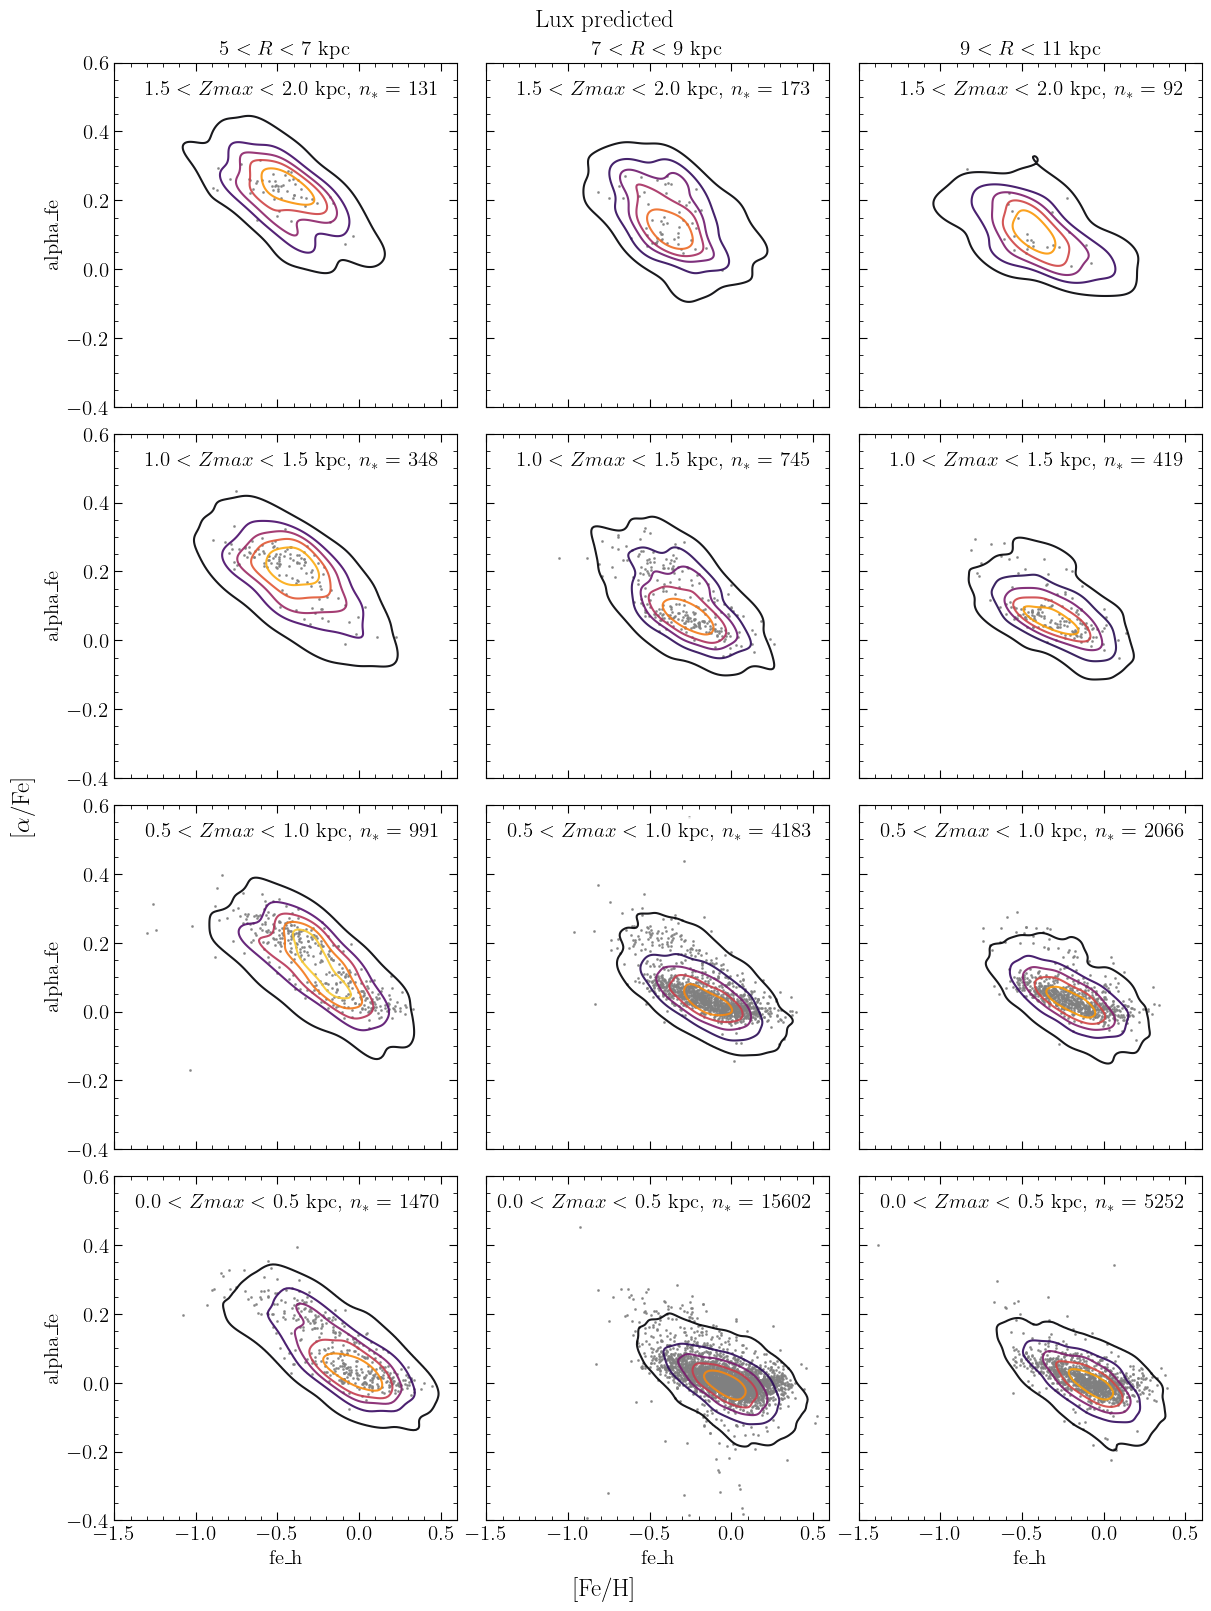

In [63]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Define the spatial bins
r_bins = np.arange(5, 13, 2)       
z_bins = np.arange(0, 2.5, 0.5)    

n_rows = len(z_bins) - 1
n_cols = len(r_bins) - 1

# 2. Set up the matplotlib grid 
fig, axes = plt.subplots(
    nrows=n_rows, 
    ncols=n_cols, 
    figsize=(12, 16), 
    sharex=True, 
    sharey=True,
    layout="constrained"
)

# 3. Iterate and plot
for i in range(n_rows):
    # Invert row index so Z=0 is at the bottom
    row_idx = n_rows - 1 - i 
    z_min, z_max = z_bins[i], z_bins[i+1]
    
    for j in range(n_cols):
        r_min, r_max = r_bins[j], r_bins[j+1]
        ax = axes[row_idx, j]
        
        # Filter the dataset
        mask = (
            (lux_pred_all['R_guide'] >= r_min) & 
            (lux_pred_all['R_guide'] < r_max) & 
            (lux_pred_all['z_max'] >= z_min) & 
            (lux_pred_all['z_max'] < z_max)
        )

        mask_sdss = (
            (training_sdss_all['R_guide'] >= r_min) & 
            (training_sdss_all['R_guide'] < r_max) & 
            (training_sdss_all['z_max'] >= z_min) & 
            (training_sdss_all['z_max'] < z_max)
        )
        
        subset = lux_pred_all[mask]
        subset_sdss = training_sdss_all[mask_sdss]
        
        # Plot background scatter
        if len(subset_sdss) > 0:
            ax.scatter(subset_sdss['fe_h'], subset_sdss['alpha_fe'], color='gray', s=1, alpha=0.8, zorder=1)
        
        # Plot Seaborn KDE contour lines on the current axis
        if len(subset) > 0:
            sns.kdeplot(
                x=subset['fe_h'], 
                y=subset['alpha_fe'], 
                ax=ax, 
                levels=6,         # Adjust this number for more or fewer contour rings
                cmap="inferno", 
                linewidths=1.5,
                alpha=0.9,
                zorder=5
            )

        # Format grid titles (R bins on top row)
        if row_idx == 0:  
            ax.set_title(fr'{r_min} $ < R < $ {r_max} kpc')
            
        # Zmax text inside every plot
        ax.text(0.95, 0.95, fr'{z_min} $ < Zmax < $ {z_max} kpc,  $n_*$ = {len(subset)}', 
                transform=ax.transAxes, 
                horizontalalignment='right', 
                verticalalignment='top',
                bbox=dict(facecolor='white', alpha=0.8, edgecolor='none'))
        
        ax.set_ylim(-0.4, 0.6)
        ax.set_xlim(-1.5, 0.6)

# 4. Add global labels
fig.supxlabel('[Fe/H]')
fig.supylabel(r'[$\alpha$/Fe]')
fig.suptitle("Lux predicted")
plt.show()

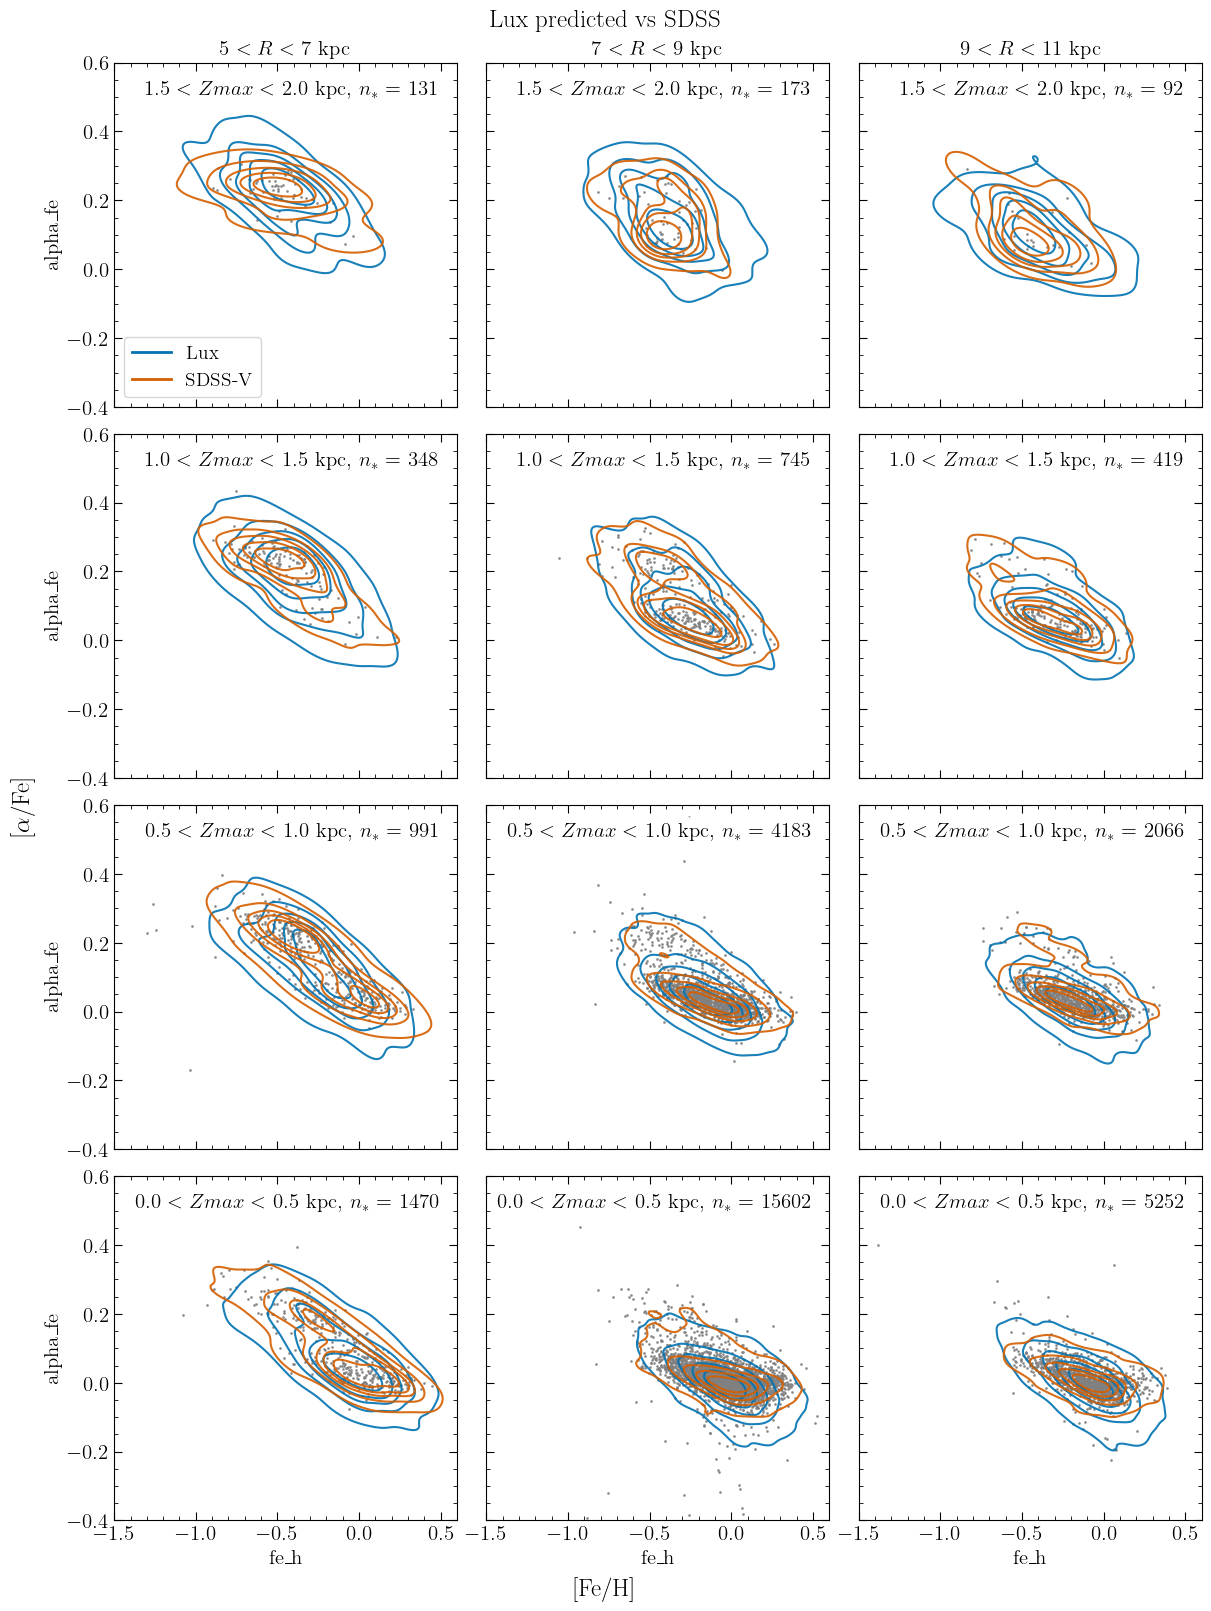

In [73]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.lines import Line2D

# 1. Define the spatial bins
r_bins = np.arange(5, 13, 2)       
z_bins = np.arange(0, 2.5, 0.5)    

n_rows = len(z_bins) - 1
n_cols = len(r_bins) - 1

# 2. Set up the matplotlib grid 
fig, axes = plt.subplots(
    nrows=n_rows, 
    ncols=n_cols, 
    figsize=(12, 16), 
    sharex=True, 
    sharey=True,
    layout="constrained"
)

# 3. Iterate and plot
for i in range(n_rows):
    # Invert row index so Z=0 is at the bottom
    row_idx = n_rows - 1 - i 
    z_min, z_max = z_bins[i], z_bins[i+1]
    
    for j in range(n_cols):
        r_min, r_max = r_bins[j], r_bins[j+1]
        ax = axes[row_idx, j]
        
        # Filter the dataset
        mask = (
            (lux_pred_all['R_guide'] >= r_min) & 
            (lux_pred_all['R_guide'] < r_max) & 
            (lux_pred_all['z_max'] >= z_min) & 
            (lux_pred_all['z_max'] < z_max)
        )

        mask_sdss = (
            (training_sdss_all['R_guide'] >= r_min) & 
            (training_sdss_all['R_guide'] < r_max) & 
            (training_sdss_all['z_max'] >= z_min) & 
            (training_sdss_all['z_max'] < z_max)
        )
        
        subset = lux_pred_all[mask]
        subset_sdss = training_sdss_all[mask_sdss]
        
        # Plot background scatter
        if len(subset_sdss) > 0:
            ax.scatter(subset_sdss['fe_h'], subset_sdss['alpha_fe'], color='gray', s=1, alpha=0.8, zorder=1)
        
        # Plot Seaborn KDE contour lines for Lux (Blue)
        if len(subset) > 0:
            sns.kdeplot(
                x=subset['fe_h'], 
                y=subset['alpha_fe'], 
                ax=ax, 
                levels=6,         
                color="#0072B2",  # Colorblind-friendly blue
                linewidths=1.5,
                alpha=0.9,
                zorder=5
            )
            
        # Plot Seaborn KDE contour lines for SDSS (Orange/Vermillion)
        if len(subset_sdss) > 0:
            sns.kdeplot(
                x=subset_sdss['fe_h'], 
                y=subset_sdss['alpha_fe'], 
                ax=ax, 
                levels=6,         
                color="#D55E00",  # Colorblind-friendly orange
                linewidths=1.5,
                alpha=0.9,
                zorder=5
            )
            
        # Custom Legend in the top-left subplot
        if row_idx == 0 and j == 0:
            # Create proxy lines for the legend
            lux_legend = Line2D([0], [0], color="#0072B2", lw=2, label='Lux')
            sdss_legend = Line2D([0], [0], color="#D55E00", lw=2, label='SDSS-V')
            
            # Place the legend in the upper left corner
            ax.legend(handles=[lux_legend, sdss_legend], loc='lower left')

        # Format grid titles (R bins on top row)
        if row_idx == 0:  
            ax.set_title(fr'{r_min} $ < R < $ {r_max} kpc')
            
        # Zmax text inside every plot
        ax.text(0.95, 0.95, fr'{z_min} $ < Zmax < $ {z_max} kpc,  $n_*$ = {len(subset)}', 
                transform=ax.transAxes, 
                horizontalalignment='right', 
                verticalalignment='top',
                bbox=dict(facecolor='white', alpha=0.8, edgecolor='none'))
        
        ax.set_ylim(-0.4, 0.6)
        ax.set_xlim(-1.5, 0.6)

# 4. Add global labels
fig.supxlabel('[Fe/H]')
fig.supylabel(r'[$\alpha$/Fe]')
fig.suptitle("Lux predicted vs SDSS")
plt.show()

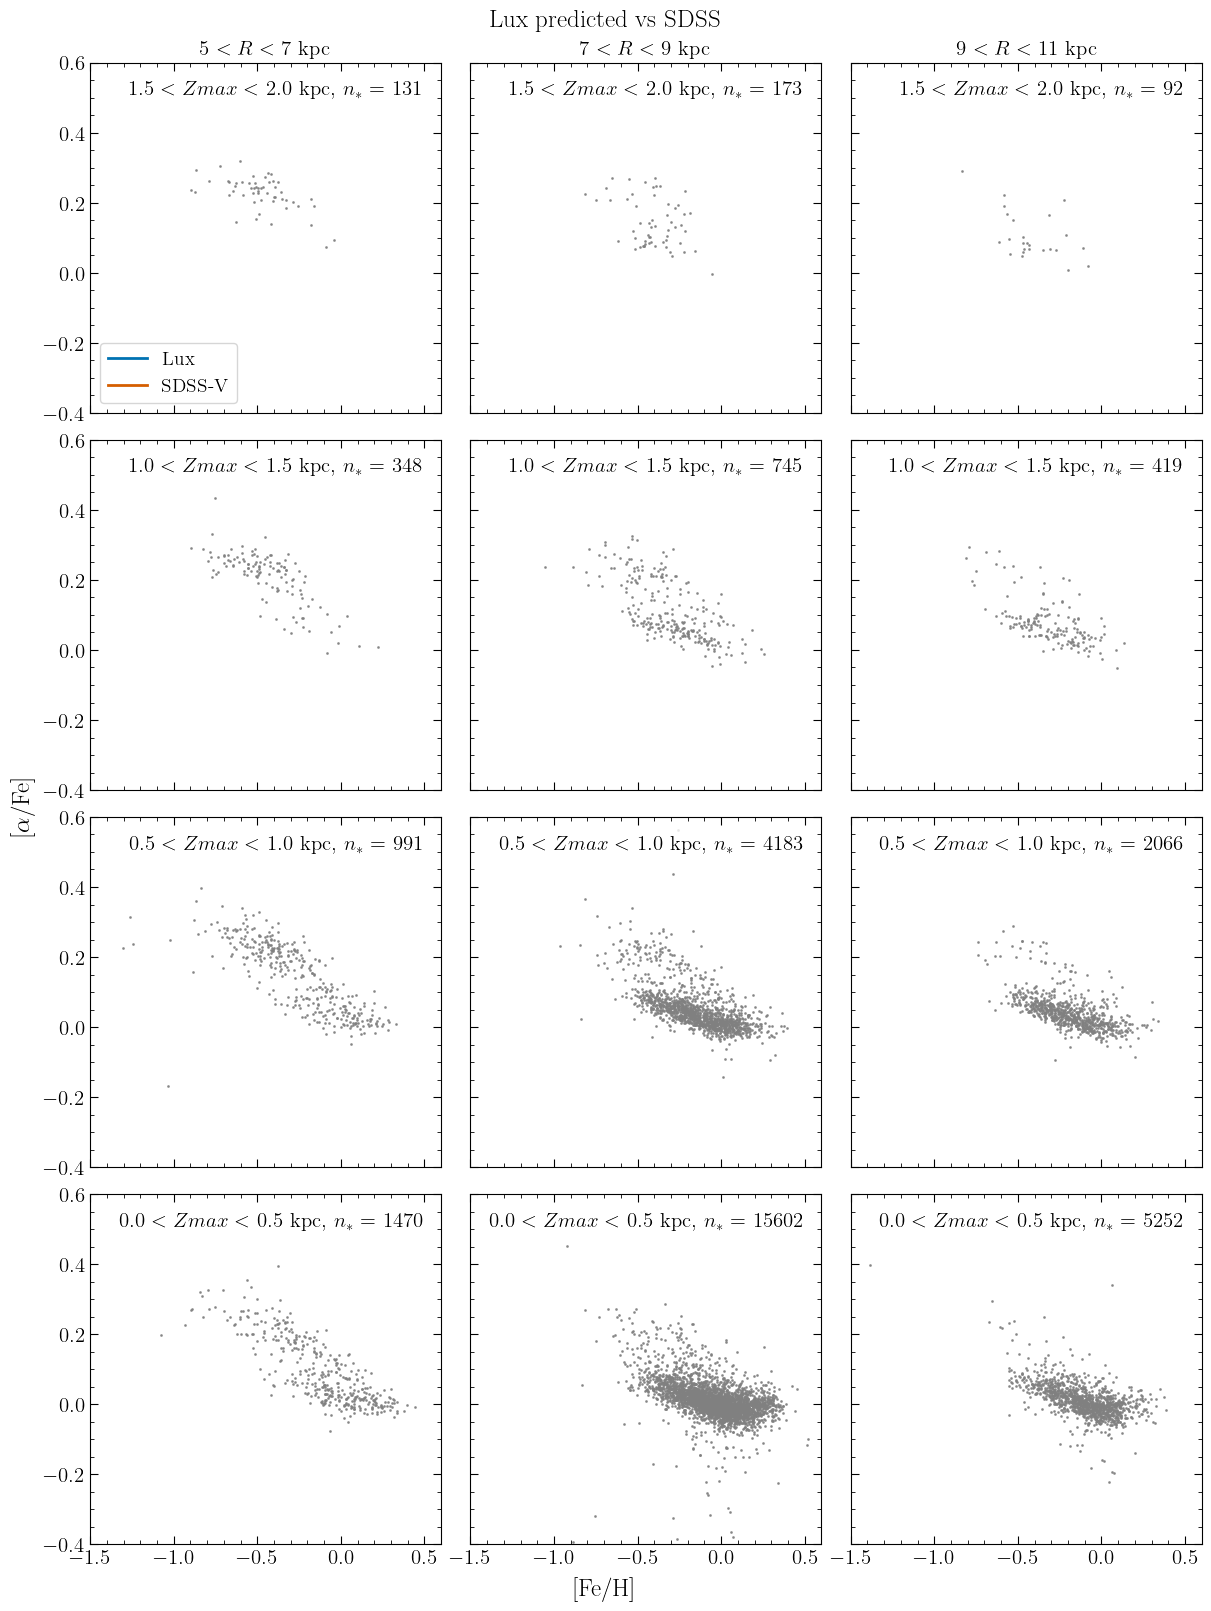

In [74]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.lines import Line2D

# 1. Define the spatial bins
r_bins = np.arange(5, 13, 2)       
z_bins = np.arange(0, 2.5, 0.5)    

n_rows = len(z_bins) - 1
n_cols = len(r_bins) - 1

# 2. Set up the matplotlib grid 
fig, axes = plt.subplots(
    nrows=n_rows, 
    ncols=n_cols, 
    figsize=(12, 16), 
    sharex=True, 
    sharey=True,
    layout="constrained"
)

# 3. Iterate and plot
for i in range(n_rows):
    # Invert row index so Z=0 is at the bottom
    row_idx = n_rows - 1 - i 
    z_min, z_max = z_bins[i], z_bins[i+1]
    
    for j in range(n_cols):
        r_min, r_max = r_bins[j], r_bins[j+1]
        ax = axes[row_idx, j]
        
        # Filter the dataset
        mask = (
            (lux_pred_all['R_guide'] >= r_min) & 
            (lux_pred_all['R_guide'] < r_max) & 
            (lux_pred_all['z_max'] >= z_min) & 
            (lux_pred_all['z_max'] < z_max)
        )

        mask_sdss = (
            (training_sdss_all['R_guide'] >= r_min) & 
            (training_sdss_all['R_guide'] < r_max) & 
            (training_sdss_all['z_max'] >= z_min) & 
            (training_sdss_all['z_max'] < z_max)
        )
        
        subset = lux_pred_all[mask]
        subset_sdss = training_sdss_all[mask_sdss]
        
        # Plot background scatter
        if len(subset_sdss) > 0:
            ax.scatter(subset_sdss['fe_h'], subset_sdss['alpha_fe'], color='gray', s=1, alpha=0.8, zorder=1)
        
        # Plot Seaborn KDE contour lines for Lux (Blue)
        #if len(subset) > 0:
        #    sns.kdeplot(x=subset['fe_h'], y=subset['alpha_fe'], ax=ax, levels=6, color="#0072B2", bluelinewidths=1.5, alpha=0.9, zorder=5)
            
        # Plot Seaborn KDE contour lines for SDSS (Orange/Vermillion)
        #if len(subset_sdss) > 0:
        #    sns.kdeplot(x=subset_sdss['fe_h'], y=subset_sdss['alpha_fe'], ax=ax, levels=6, color="#D55E00", linewidths=1.5,alpha=0.9,zorder=5)
            
        # Custom Legend in the top-left subplot
        if row_idx == 0 and j == 0:
            # Create proxy lines for the legend
            lux_legend = Line2D([0], [0], color="#0072B2", lw=2, label='Lux')
            sdss_legend = Line2D([0], [0], color="#D55E00", lw=2, label='SDSS-V')
            
            # Place the legend in the upper left corner
            ax.legend(handles=[lux_legend, sdss_legend], loc='lower left')

        # Format grid titles (R bins on top row)
        if row_idx == 0:  
            ax.set_title(fr'{r_min} $ < R < $ {r_max} kpc')
            
        # Zmax text inside every plot
        ax.text(0.95, 0.95, fr'{z_min} $ < Zmax < $ {z_max} kpc,  $n_*$ = {len(subset)}', 
                transform=ax.transAxes, 
                horizontalalignment='right', 
                verticalalignment='top',
                bbox=dict(facecolor='white', alpha=0.8, edgecolor='none'))
        
        ax.set_ylim(-0.4, 0.6)
        ax.set_xlim(-1.5, 0.6)

# 4. Add global labels
fig.supxlabel('[Fe/H]')
fig.supylabel(r'[$\alpha$/Fe]')
fig.suptitle("Lux predicted vs SDSS")
plt.show()

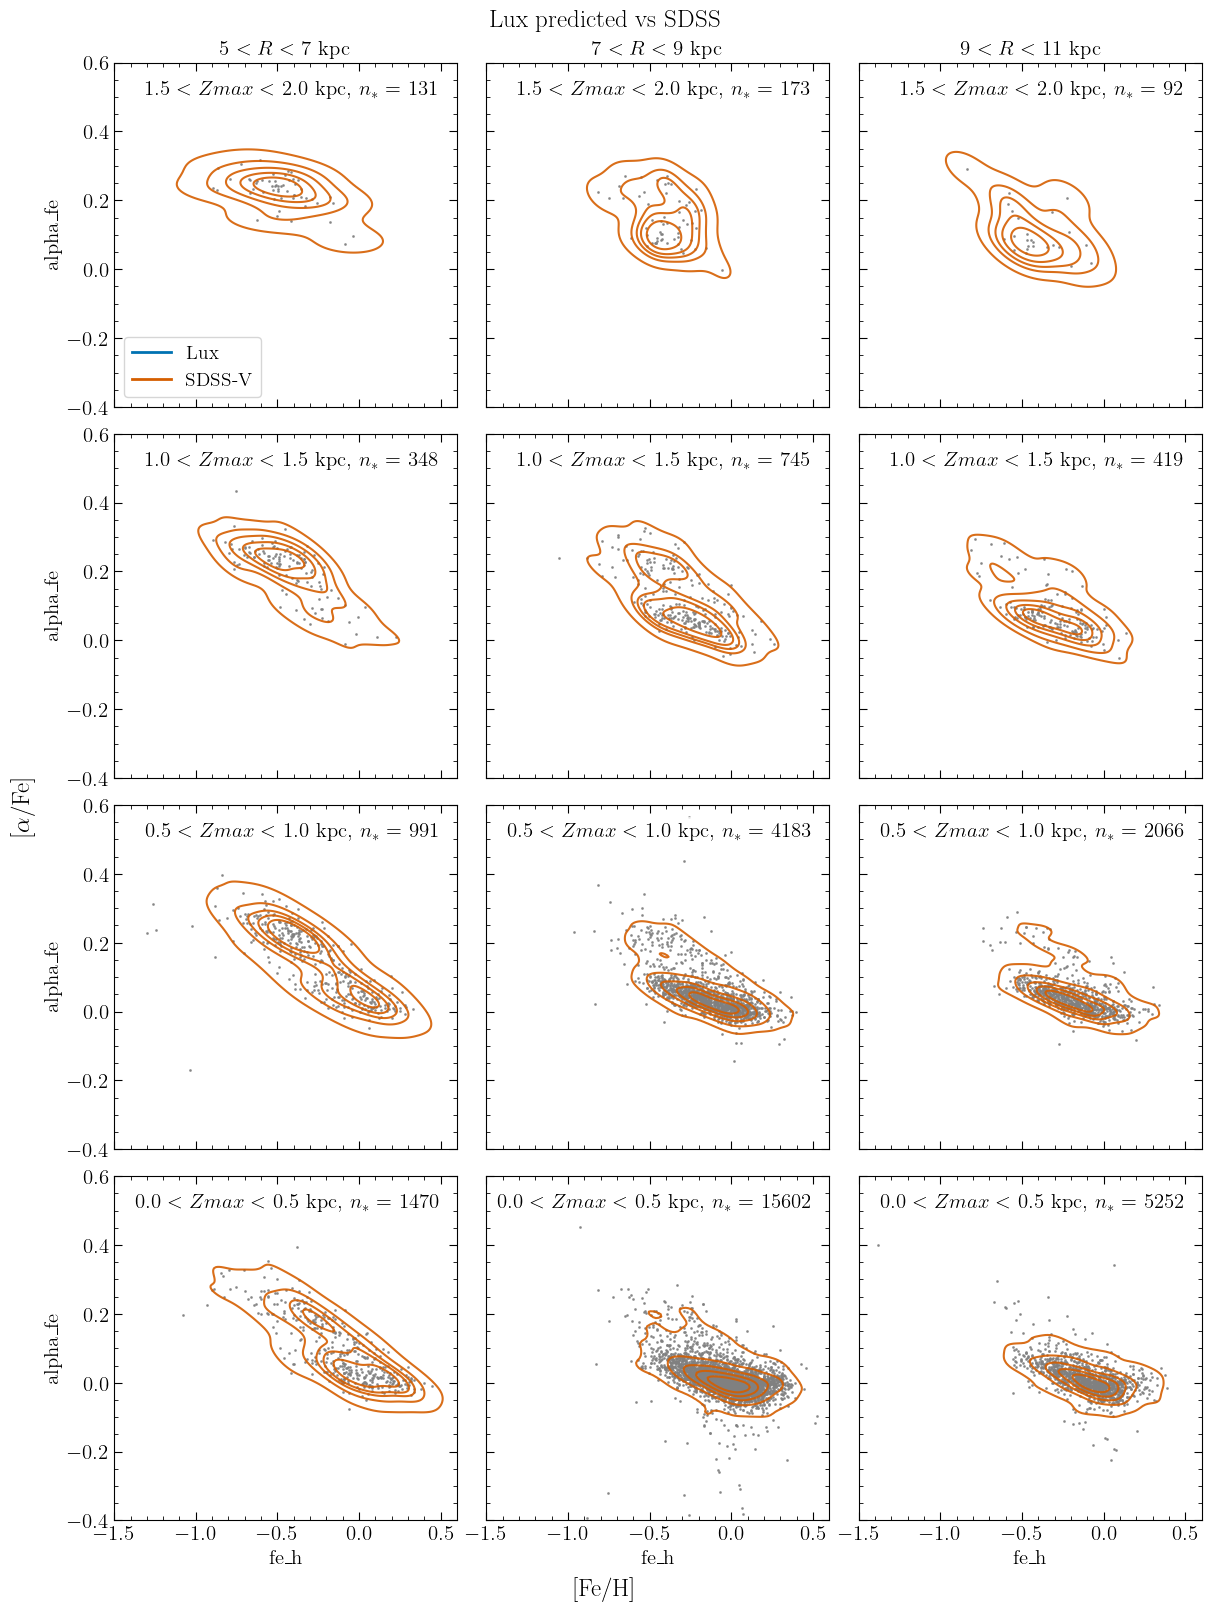

In [75]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.lines import Line2D

# 1. Define the spatial bins
r_bins = np.arange(5, 13, 2)       
z_bins = np.arange(0, 2.5, 0.5)    

n_rows = len(z_bins) - 1
n_cols = len(r_bins) - 1

# 2. Set up the matplotlib grid 
fig, axes = plt.subplots(
    nrows=n_rows, 
    ncols=n_cols, 
    figsize=(12, 16), 
    sharex=True, 
    sharey=True,
    layout="constrained"
)

# 3. Iterate and plot
for i in range(n_rows):
    # Invert row index so Z=0 is at the bottom
    row_idx = n_rows - 1 - i 
    z_min, z_max = z_bins[i], z_bins[i+1]
    
    for j in range(n_cols):
        r_min, r_max = r_bins[j], r_bins[j+1]
        ax = axes[row_idx, j]
        
        # Filter the dataset
        mask = (
            (lux_pred_all['R_guide'] >= r_min) & 
            (lux_pred_all['R_guide'] < r_max) & 
            (lux_pred_all['z_max'] >= z_min) & 
            (lux_pred_all['z_max'] < z_max)
        )

        mask_sdss = (
            (training_sdss_all['R_guide'] >= r_min) & 
            (training_sdss_all['R_guide'] < r_max) & 
            (training_sdss_all['z_max'] >= z_min) & 
            (training_sdss_all['z_max'] < z_max)
        )
        
        subset = lux_pred_all[mask]
        subset_sdss = training_sdss_all[mask_sdss]
        
        # Plot background scatter
        if len(subset_sdss) > 0:
            ax.scatter(subset_sdss['fe_h'], subset_sdss['alpha_fe'], color='gray', s=1, alpha=0.8, zorder=1)
        
        # Plot Seaborn KDE contour lines for Lux (Blue)
        #if len(subset) > 0:
        #    sns.kdeplot(x=subset['fe_h'], y=subset['alpha_fe'], ax=ax, levels=6, color="#0072B2", bluelinewidths=1.5, alpha=0.9, zorder=5)
            
        # Plot Seaborn KDE contour lines for SDSS (Orange/Vermillion)
        if len(subset_sdss) > 0:
            sns.kdeplot(x=subset_sdss['fe_h'], y=subset_sdss['alpha_fe'], ax=ax, levels=6, color="#D55E00", linewidths=1.5,alpha=0.9,zorder=5)
            
        # Custom Legend in the top-left subplot
        if row_idx == 0 and j == 0:
            # Create proxy lines for the legend
            lux_legend = Line2D([0], [0], color="#0072B2", lw=2, label='Lux')
            sdss_legend = Line2D([0], [0], color="#D55E00", lw=2, label='SDSS-V')
            
            # Place the legend in the upper left corner
            ax.legend(handles=[lux_legend, sdss_legend], loc='lower left')

        # Format grid titles (R bins on top row)
        if row_idx == 0:  
            ax.set_title(fr'{r_min} $ < R < $ {r_max} kpc')
            
        # Zmax text inside every plot
        ax.text(0.95, 0.95, fr'{z_min} $ < Zmax < $ {z_max} kpc,  $n_*$ = {len(subset)}', 
                transform=ax.transAxes, 
                horizontalalignment='right', 
                verticalalignment='top',
                bbox=dict(facecolor='white', alpha=0.8, edgecolor='none'))
        
        ax.set_ylim(-0.4, 0.6)
        ax.set_xlim(-1.5, 0.6)

# 4. Add global labels
fig.supxlabel('[Fe/H]')
fig.supylabel(r'[$\alpha$/Fe]')
fig.suptitle("Lux predicted vs SDSS")
plt.show()

/Users/honeyeah/miniconda3/envs/haniyeh_research/lib/python3.13/site-packages/seaborn/distributions.py:1176: UserWarning: The following kwargs were not used by contour: 'bluelinewidths'
  cset = contour_func(
/Users/honeyeah/miniconda3/envs/haniyeh_research/lib/python3.13/site-packages/seaborn/distributions.py:1176: UserWarning: The following kwargs were not used by contour: 'bluelinewidths'
  cset = contour_func(
/Users/honeyeah/miniconda3/envs/haniyeh_research/lib/python3.13/site-packages/seaborn/distributions.py:1176: UserWarning: The following kwargs were not used by contour: 'bluelinewidths'
  cset = contour_func(
/Users/honeyeah/miniconda3/envs/haniyeh_research/lib/python3.13/site-packages/seaborn/distributions.py:1176: UserWarning: The following kwargs were not used by contour: 'bluelinewidths'
  cset = contour_func(
/Users/honeyeah/miniconda3/envs/haniyeh_research/lib/python3.13/site-packages/seaborn/distributions.py:1176: UserWarning: The following kwargs were not used by cont

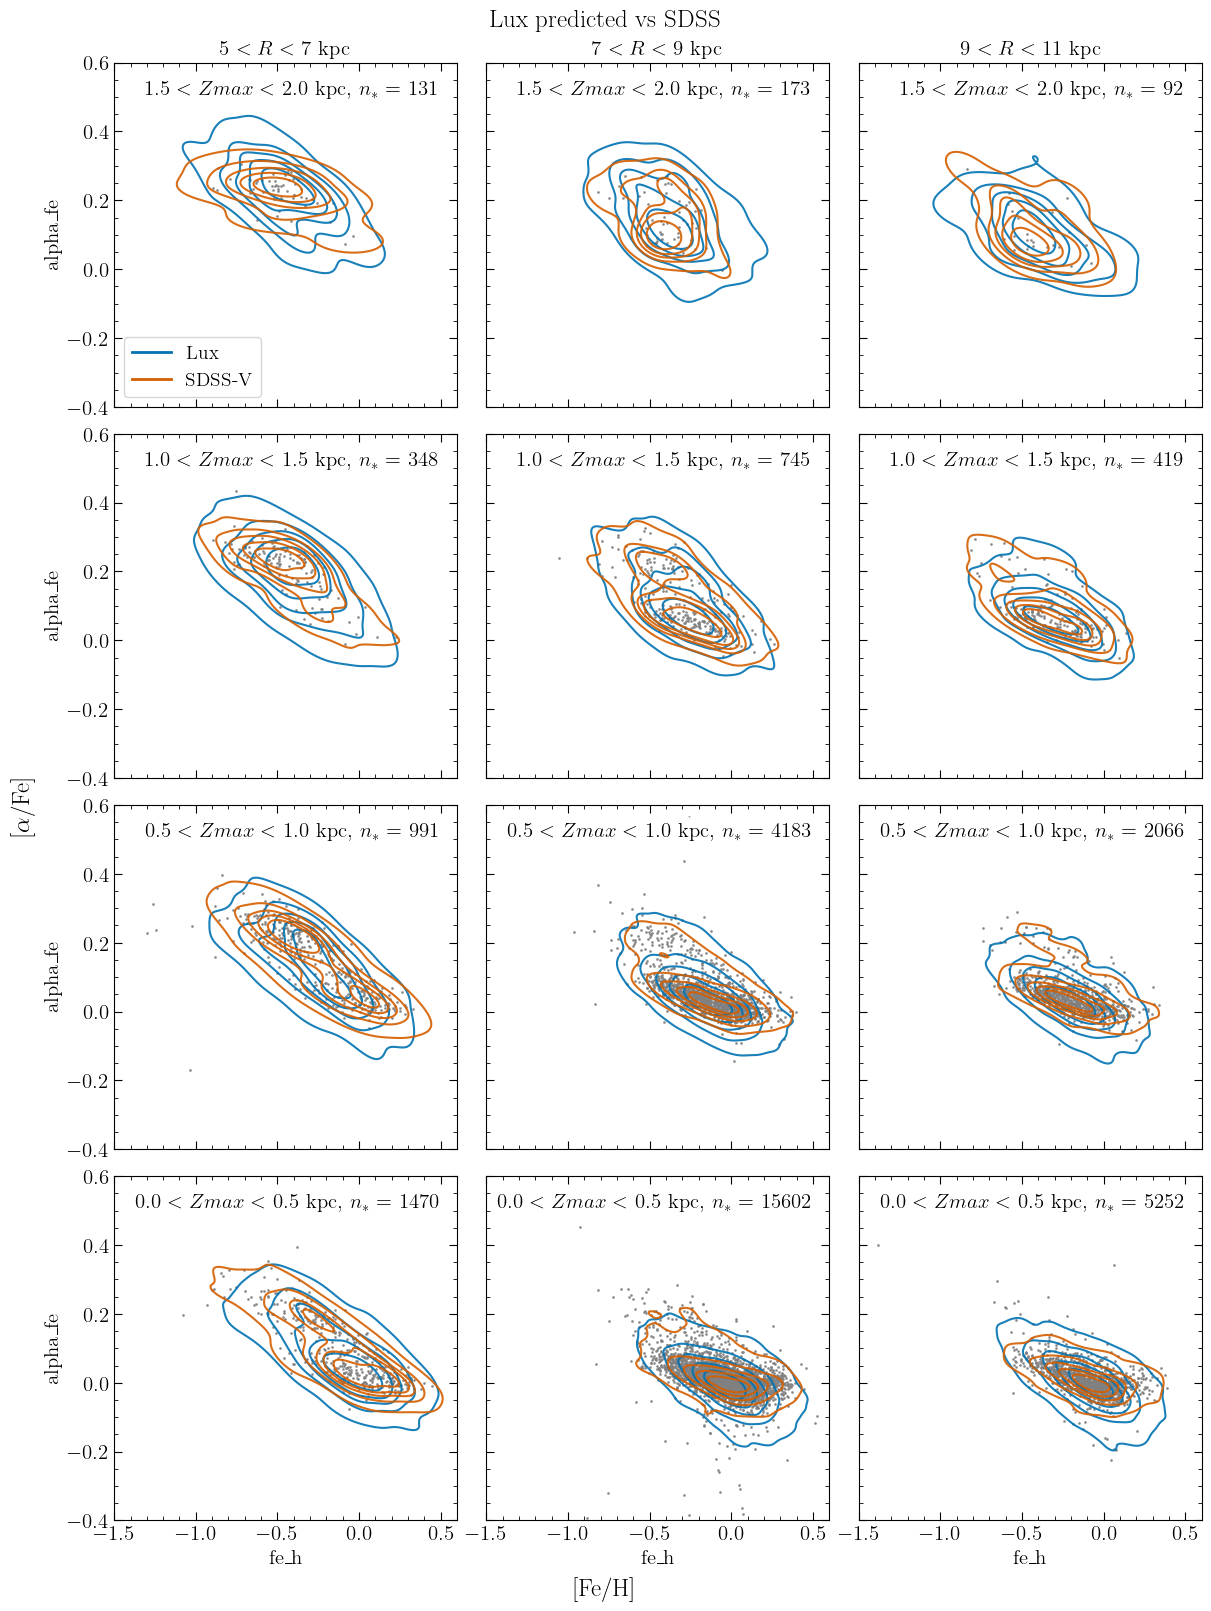

In [76]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.lines import Line2D

# 1. Define the spatial bins
r_bins = np.arange(5, 13, 2)       
z_bins = np.arange(0, 2.5, 0.5)    

n_rows = len(z_bins) - 1
n_cols = len(r_bins) - 1

# 2. Set up the matplotlib grid 
fig, axes = plt.subplots(
    nrows=n_rows, 
    ncols=n_cols, 
    figsize=(12, 16), 
    sharex=True, 
    sharey=True,
    layout="constrained"
)

# 3. Iterate and plot
for i in range(n_rows):
    # Invert row index so Z=0 is at the bottom
    row_idx = n_rows - 1 - i 
    z_min, z_max = z_bins[i], z_bins[i+1]
    
    for j in range(n_cols):
        r_min, r_max = r_bins[j], r_bins[j+1]
        ax = axes[row_idx, j]
        
        # Filter the dataset
        mask = (
            (lux_pred_all['R_guide'] >= r_min) & 
            (lux_pred_all['R_guide'] < r_max) & 
            (lux_pred_all['z_max'] >= z_min) & 
            (lux_pred_all['z_max'] < z_max)
        )

        mask_sdss = (
            (training_sdss_all['R_guide'] >= r_min) & 
            (training_sdss_all['R_guide'] < r_max) & 
            (training_sdss_all['z_max'] >= z_min) & 
            (training_sdss_all['z_max'] < z_max)
        )
        
        subset = lux_pred_all[mask]
        subset_sdss = training_sdss_all[mask_sdss]
        
        # Plot background scatter
        if len(subset_sdss) > 0:
            ax.scatter(subset_sdss['fe_h'], subset_sdss['alpha_fe'], color='gray', s=1, alpha=0.8, zorder=1)
        
        # Plot Seaborn KDE contour lines for Lux (Blue)
        if len(subset) > 0:
            sns.kdeplot(x=subset['fe_h'], y=subset['alpha_fe'], ax=ax, levels=6, color="#0072B2", bluelinewidths=1.5, alpha=0.9, zorder=5)
            
        # Plot Seaborn KDE contour lines for SDSS (Orange/Vermillion)
        if len(subset_sdss) > 0:
            sns.kdeplot(x=subset_sdss['fe_h'], y=subset_sdss['alpha_fe'], ax=ax, levels=6, color="#D55E00", linewidths=1.5,alpha=0.9,zorder=5)
            
        # Custom Legend in the top-left subplot
        if row_idx == 0 and j == 0:
            # Create proxy lines for the legend
            lux_legend = Line2D([0], [0], color="#0072B2", lw=2, label='Lux')
            sdss_legend = Line2D([0], [0], color="#D55E00", lw=2, label='SDSS-V')
            
            # Place the legend in the upper left corner
            ax.legend(handles=[lux_legend, sdss_legend], loc='lower left')

        # Format grid titles (R bins on top row)
        if row_idx == 0:  
            ax.set_title(fr'{r_min} $ < R < $ {r_max} kpc')
            
        # Zmax text inside every plot
        ax.text(0.95, 0.95, fr'{z_min} $ < Zmax < $ {z_max} kpc,  $n_*$ = {len(subset)}', 
                transform=ax.transAxes, 
                horizontalalignment='right', 
                verticalalignment='top',
                bbox=dict(facecolor='white', alpha=0.8, edgecolor='none'))
        
        ax.set_ylim(-0.4, 0.6)
        ax.set_xlim(-1.5, 0.6)

# 4. Add global labels
fig.supxlabel('[Fe/H]')
fig.supylabel(r'[$\alpha$/Fe]')
fig.suptitle("Lux predicted vs SDSS")
plt.show()

/Users/honeyeah/miniconda3/envs/haniyeh_research/lib/python3.13/site-packages/seaborn/distributions.py:1176: UserWarning: The following kwargs were not used by contour: 'bluelinewidths'
  cset = contour_func(
/Users/honeyeah/miniconda3/envs/haniyeh_research/lib/python3.13/site-packages/seaborn/distributions.py:1176: UserWarning: The following kwargs were not used by contour: 'bluelinewidths'
  cset = contour_func(
/Users/honeyeah/miniconda3/envs/haniyeh_research/lib/python3.13/site-packages/seaborn/distributions.py:1176: UserWarning: The following kwargs were not used by contour: 'bluelinewidths'
  cset = contour_func(
/Users/honeyeah/miniconda3/envs/haniyeh_research/lib/python3.13/site-packages/seaborn/distributions.py:1176: UserWarning: The following kwargs were not used by contour: 'bluelinewidths'
  cset = contour_func(
/Users/honeyeah/miniconda3/envs/haniyeh_research/lib/python3.13/site-packages/seaborn/distributions.py:1176: UserWarning: The following kwargs were not used by cont

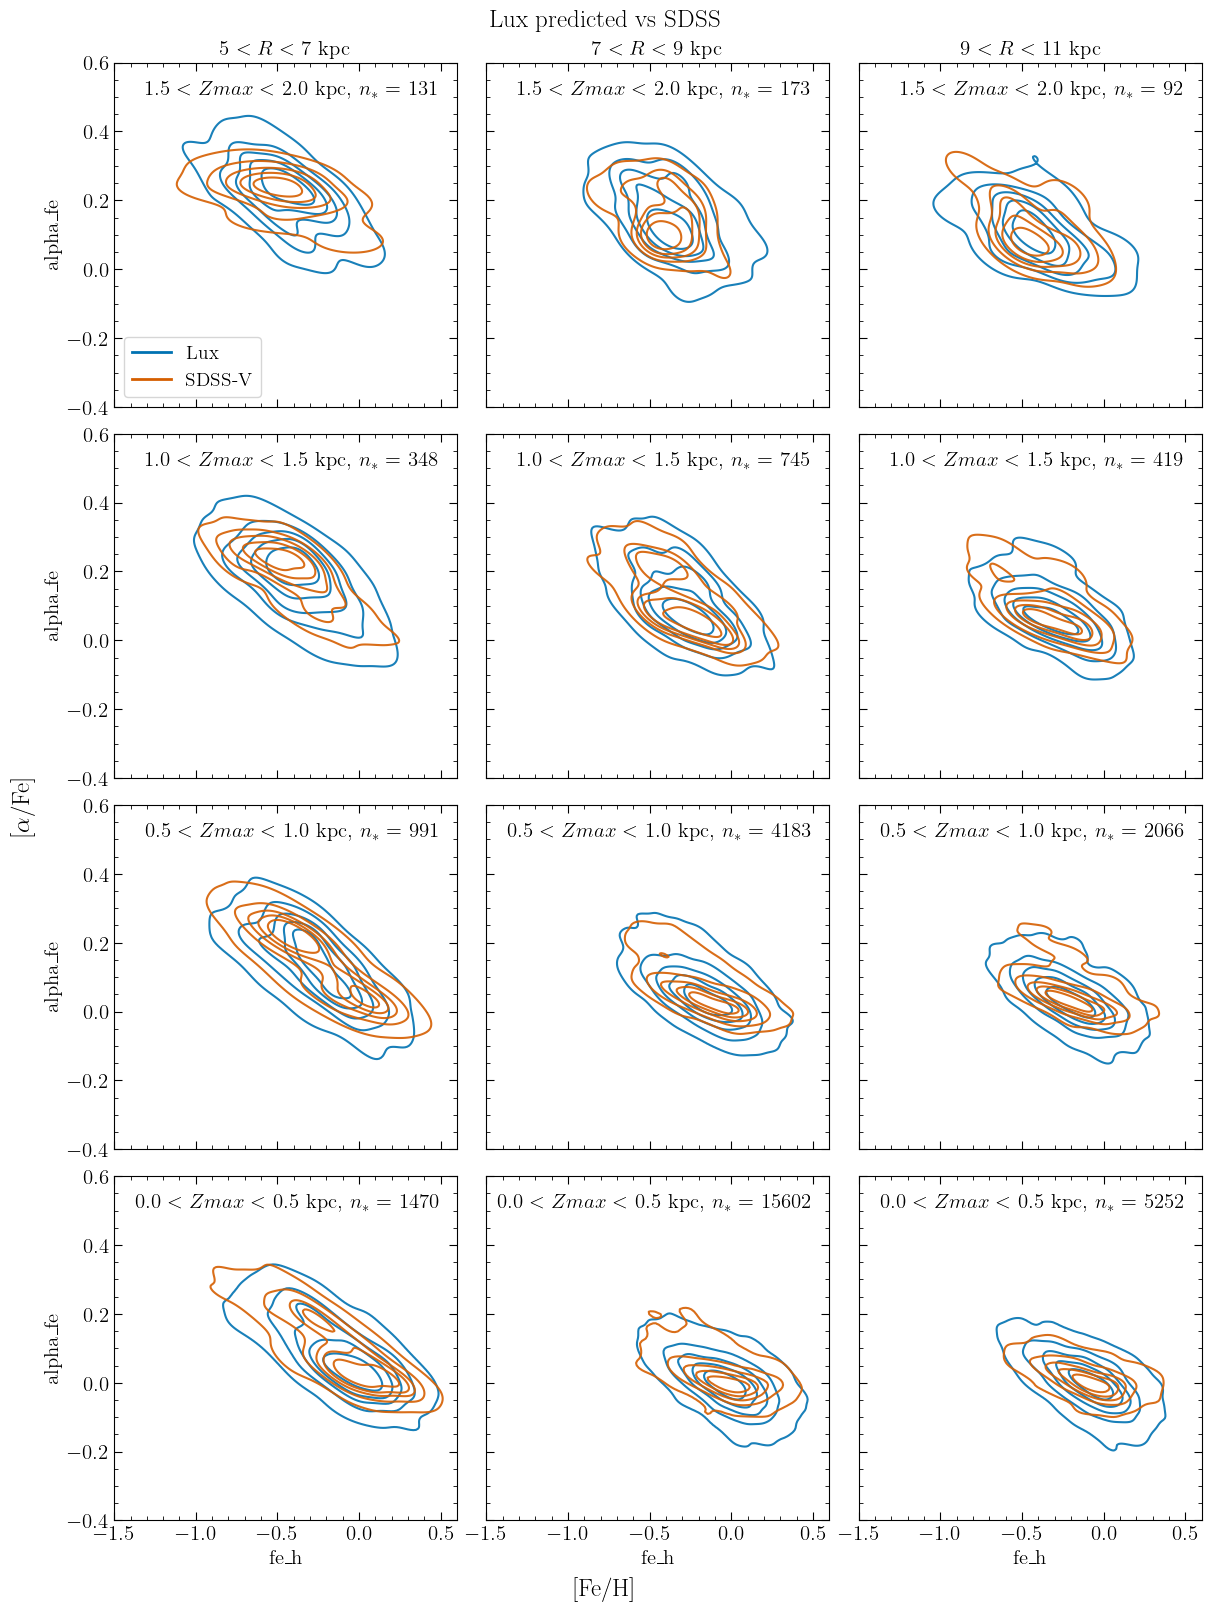

In [77]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.lines import Line2D

# 1. Define the spatial bins
r_bins = np.arange(5, 13, 2)       
z_bins = np.arange(0, 2.5, 0.5)    

n_rows = len(z_bins) - 1
n_cols = len(r_bins) - 1

# 2. Set up the matplotlib grid 
fig, axes = plt.subplots(
    nrows=n_rows, 
    ncols=n_cols, 
    figsize=(12, 16), 
    sharex=True, 
    sharey=True,
    layout="constrained"
)

# 3. Iterate and plot
for i in range(n_rows):
    # Invert row index so Z=0 is at the bottom
    row_idx = n_rows - 1 - i 
    z_min, z_max = z_bins[i], z_bins[i+1]
    
    for j in range(n_cols):
        r_min, r_max = r_bins[j], r_bins[j+1]
        ax = axes[row_idx, j]
        
        # Filter the dataset
        mask = (
            (lux_pred_all['R_guide'] >= r_min) & 
            (lux_pred_all['R_guide'] < r_max) & 
            (lux_pred_all['z_max'] >= z_min) & 
            (lux_pred_all['z_max'] < z_max)
        )

        mask_sdss = (
            (training_sdss_all['R_guide'] >= r_min) & 
            (training_sdss_all['R_guide'] < r_max) & 
            (training_sdss_all['z_max'] >= z_min) & 
            (training_sdss_all['z_max'] < z_max)
        )
        
        subset = lux_pred_all[mask]
        subset_sdss = training_sdss_all[mask_sdss]
        
        # Plot background scatter
        #if len(subset_sdss) > 0:
        #    ax.scatter(subset_sdss['fe_h'], subset_sdss['alpha_fe'], color='gray', s=1, alpha=0.8, zorder=1)
        
        # Plot Seaborn KDE contour lines for Lux (Blue)
        if len(subset) > 0:
            sns.kdeplot(x=subset['fe_h'], y=subset['alpha_fe'], ax=ax, levels=6, color="#0072B2", bluelinewidths=1.5, alpha=0.9, zorder=5)
            
        # Plot Seaborn KDE contour lines for SDSS (Orange/Vermillion)
        if len(subset_sdss) > 0:
            sns.kdeplot(x=subset_sdss['fe_h'], y=subset_sdss['alpha_fe'], ax=ax, levels=6, color="#D55E00", linewidths=1.5,alpha=0.9,zorder=5)
            
        # Custom Legend in the top-left subplot
        if row_idx == 0 and j == 0:
            # Create proxy lines for the legend
            lux_legend = Line2D([0], [0], color="#0072B2", lw=2, label='Lux')
            sdss_legend = Line2D([0], [0], color="#D55E00", lw=2, label='SDSS-V')
            
            # Place the legend in the upper left corner
            ax.legend(handles=[lux_legend, sdss_legend], loc='lower left')

        # Format grid titles (R bins on top row)
        if row_idx == 0:  
            ax.set_title(fr'{r_min} $ < R < $ {r_max} kpc')
            
        # Zmax text inside every plot
        ax.text(0.95, 0.95, fr'{z_min} $ < Zmax < $ {z_max} kpc,  $n_*$ = {len(subset)}', 
                transform=ax.transAxes, 
                horizontalalignment='right', 
                verticalalignment='top',
                bbox=dict(facecolor='white', alpha=0.8, edgecolor='none'))
        
        ax.set_ylim(-0.4, 0.6)
        ax.set_xlim(-1.5, 0.6)

# 4. Add global labels
fig.supxlabel('[Fe/H]')
fig.supylabel(r'[$\alpha$/Fe]')
fig.suptitle("Lux predicted vs SDSS")
plt.show()